# Summary of text descriptives

In [33]:
# import modules
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as cm
import numpy as np
import seaborn as sns

In [131]:
# import descriptives
descriptives = pd.read_csv("data/corpus_descriptives.csv")

descriptives["text_type"] = [
    "novel" if "synopsis" in text_type else text_type for text_type in descriptives["text_type"]
    ]

### Plot descriptives

In [106]:
# plotting functions


def plot_descriptives(df: pd.DataFrame, parameter: str, save_fig: bool=False):
    if f"{parameter}_mean" in df.columns:
        df = df.sort_values(by=f"{parameter}_mean")
    else:
        df = df.sort_values(by=parameter)

    df["x"] = range(len(df.index))
    _ = plt.figure(figsize=(20, 9))

    groups = df.groupby("text_type")
    palette = [cm.to_hex(plt.cm.tab10(i)) for i in range(10)]

    for color, (name, group) in zip(palette, groups):
        x = group["x"]

        if f"{parameter}_mean" in df.columns:
            y = group[f"{parameter}_mean"]
            y_std = group[f"{parameter}_std"]
            plt.errorbar(x, y, yerr=y_std, fmt="o", label=name, markersize=10, color=color)
        else:
            y = group[parameter]
            plt.errorbar(x, y, fmt="o", label=name, markersize=10, color=color)
        plt.ylabel(parameter)

    text_names = df["file_name"]
    plt.xticks(df["x"], text_names, rotation=90)
    plt.grid(color="grey")
    plt.legend()
    if save_fig:
        plt.savefig(f"figs/{parameter}.png", bbox_inches="tight")
    plt.show()


def plot_descriptives_group_mean(df: pd.DataFrame, parameter: str, save_fig: bool=False):
    _ = plt.figure(figsize=(20, 9))

    groups = df.groupby("text_type")

    x, y, y_std = [], [], []
    for name, group in groups:
        x.append(name)
        y.append(np.mean(group[parameter]))
        y_std.append(np.std(group[parameter]))
    
    plt.errorbar(x, y, yerr=y_std, fmt="o", markersize=10)
    plt.xticks(rotation=90)
    plt.ylabel(parameter)

    if save_fig:
        plt.savefig(f"figs/{parameter}_group_mean.png", bbox_inches="tight")
    plt.show()


def plot_relevant_parameters(
        df: pd.DataFrame,
        x_parameter: str, 
        y_parameter: str, 
        color_parameter: str=None,
        title: str=None,
        save_fig: bool=False):
    
    sns.relplot(
        data=df, 
        x=x_parameter, 
        y=y_parameter, 
        hue=color_parameter
    )

    for i, txt in enumerate(df["Number"]):
        plt.annotate(txt, (df[x_parameter][i], df[y_parameter][i]))
    
    if title:
        plt.title(title)

    if save_fig:
        plt.savefig(f"figs/{x_parameter}_and_{y_parameter}.png", bbox_inches="tight")
    plt.show()

**Parameter values for each text**

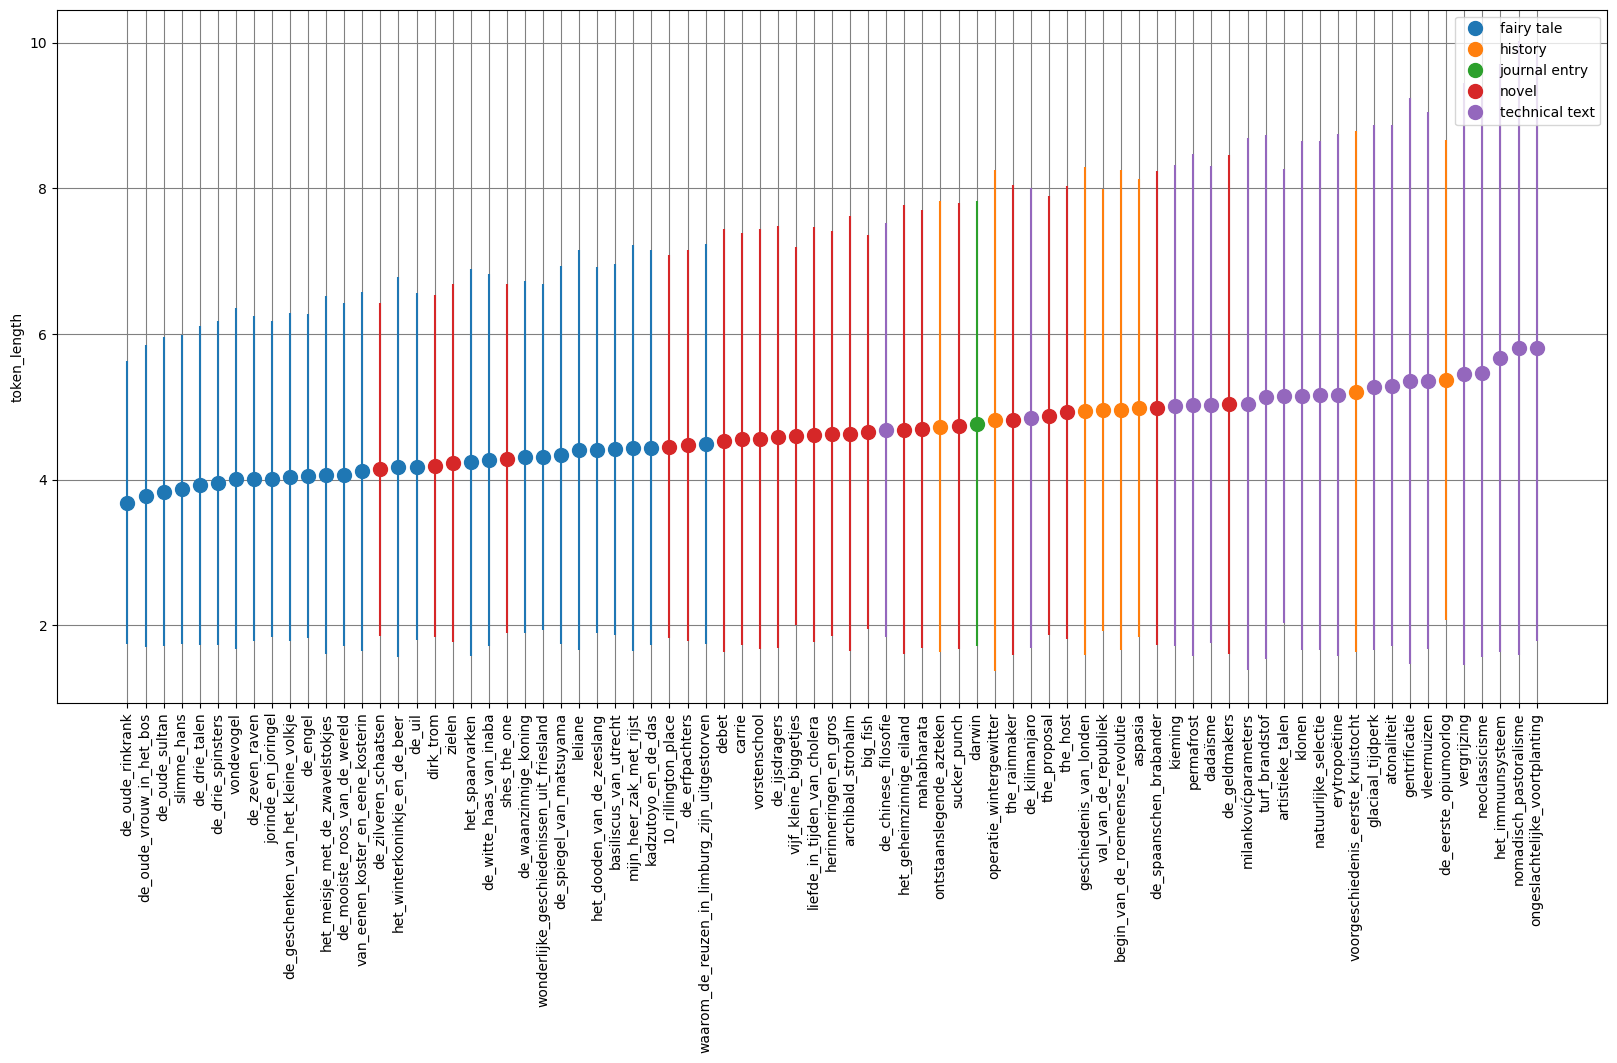

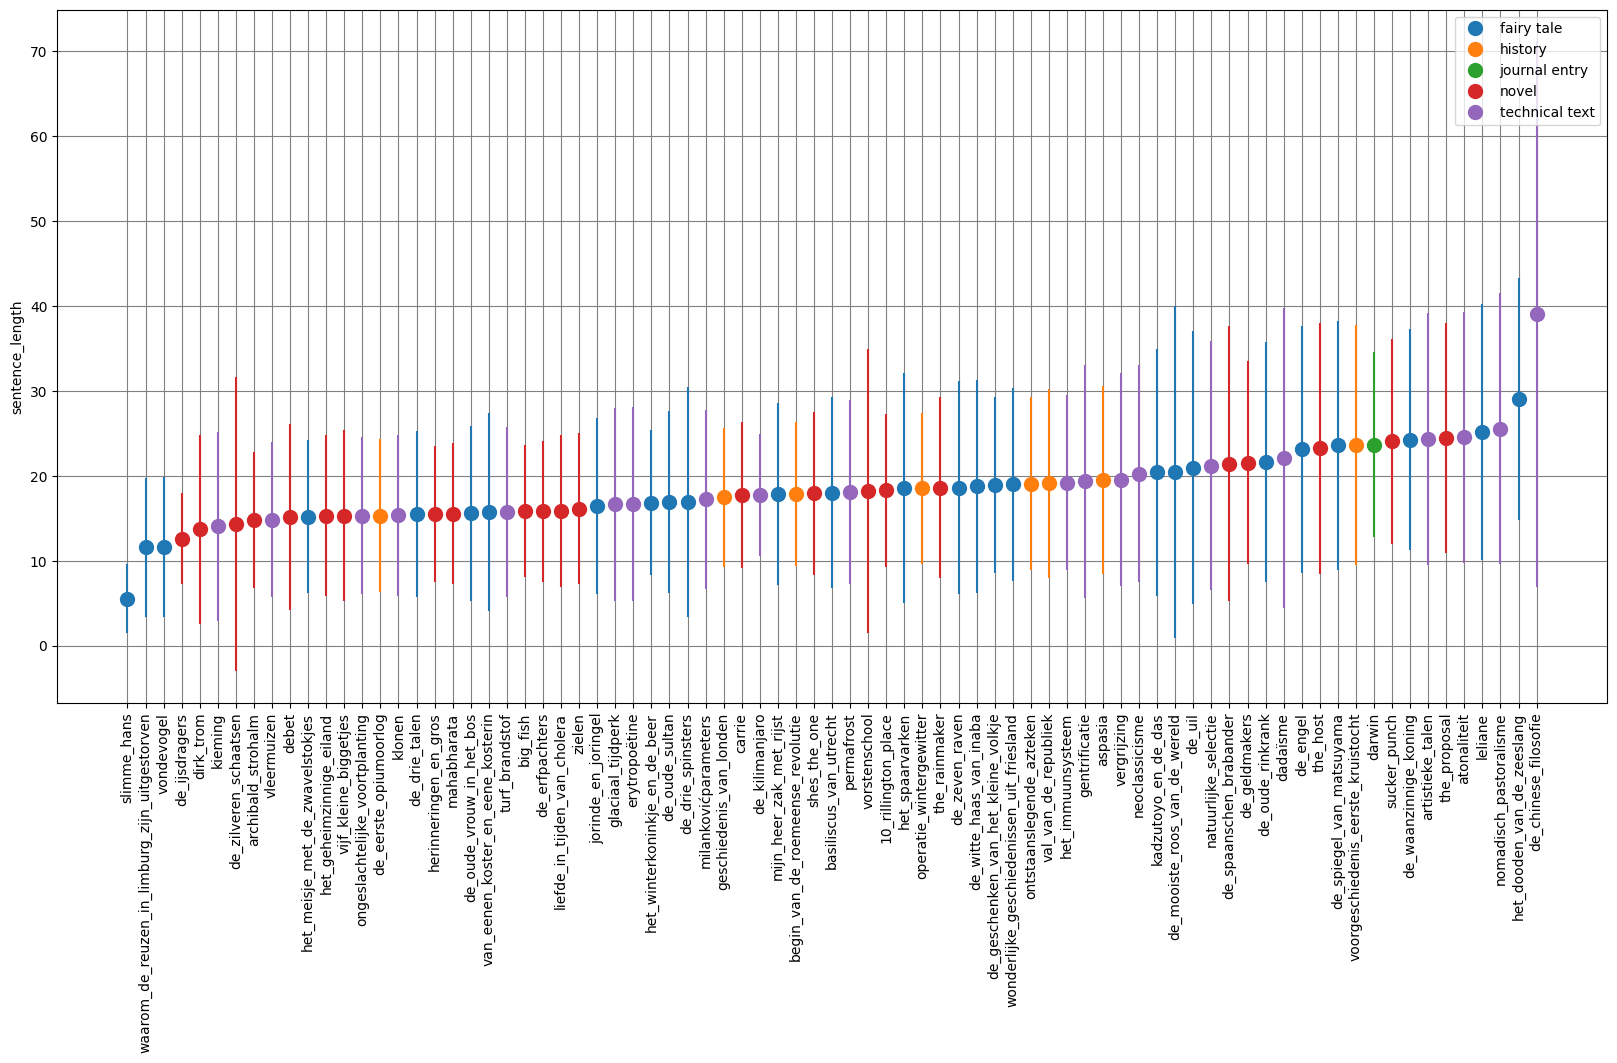

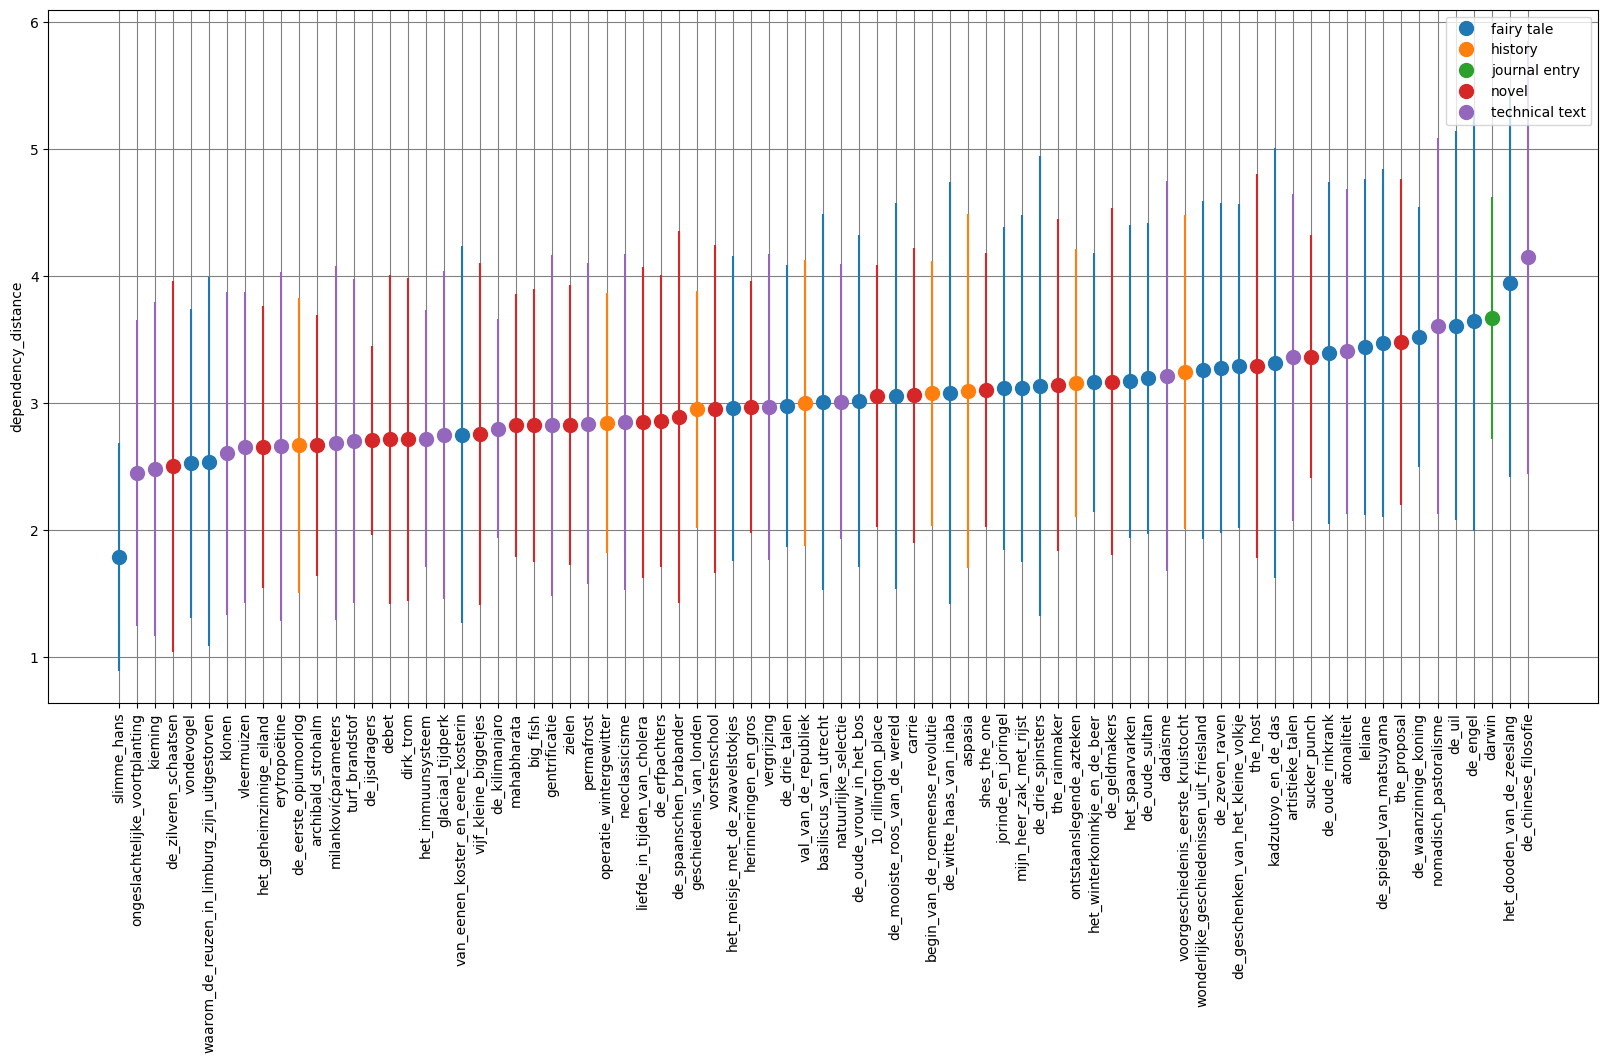

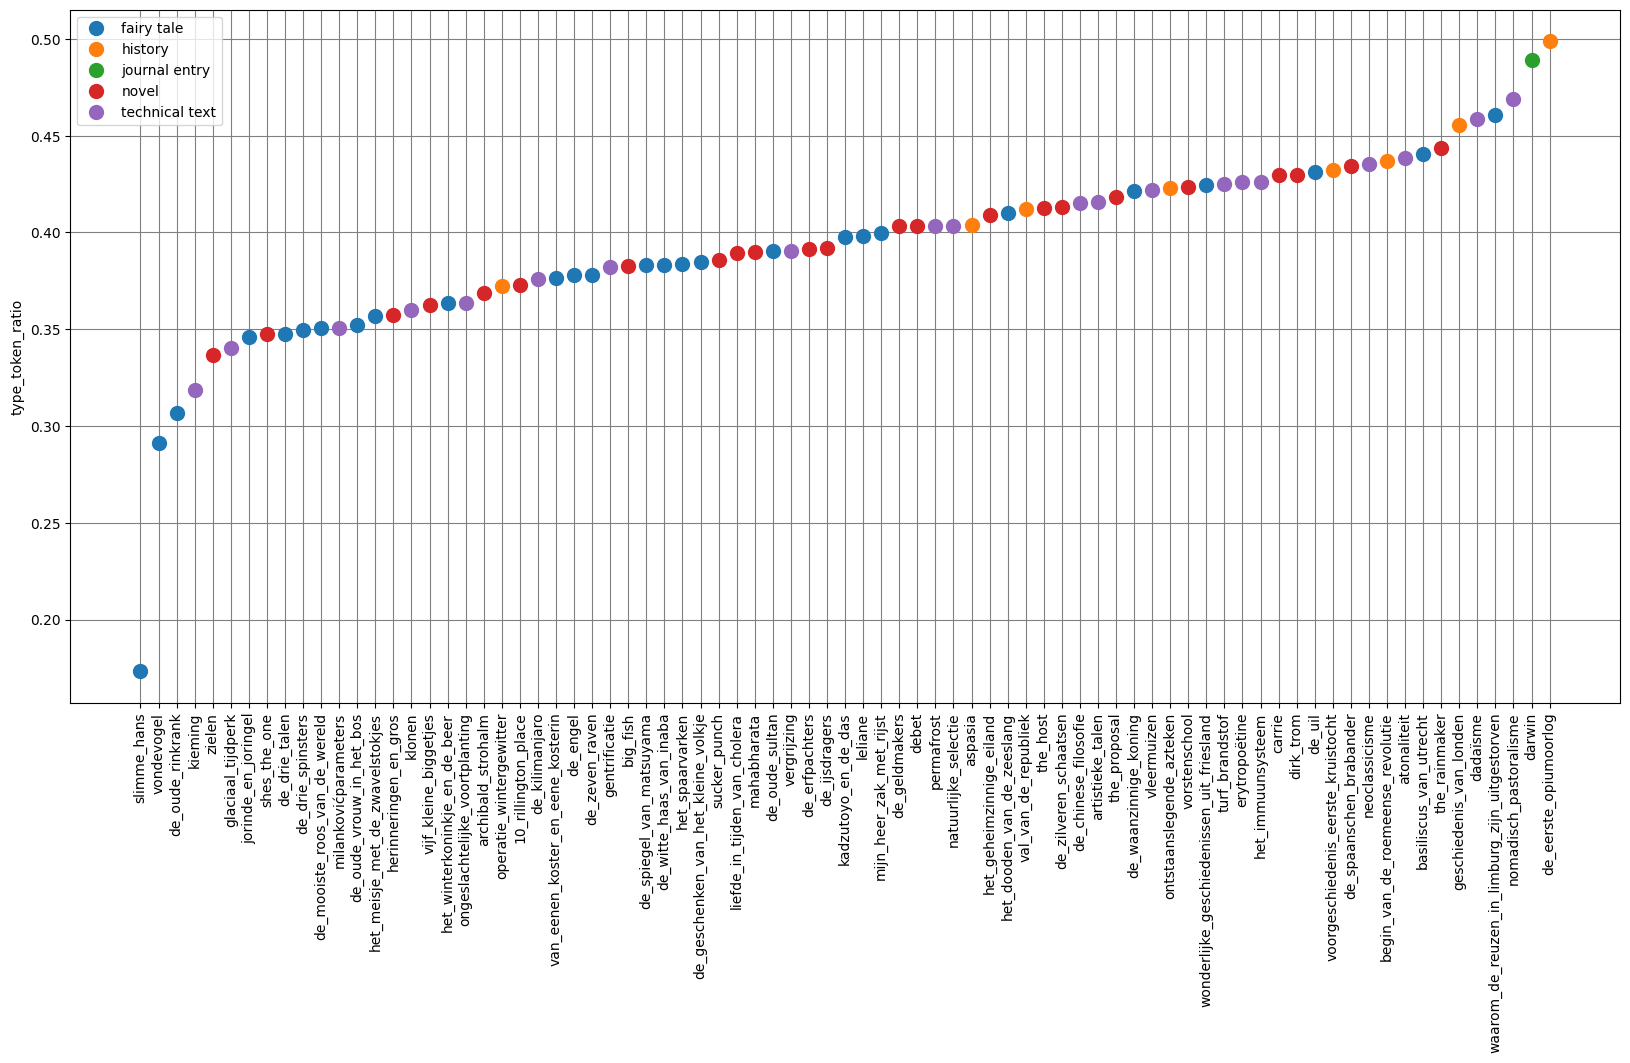

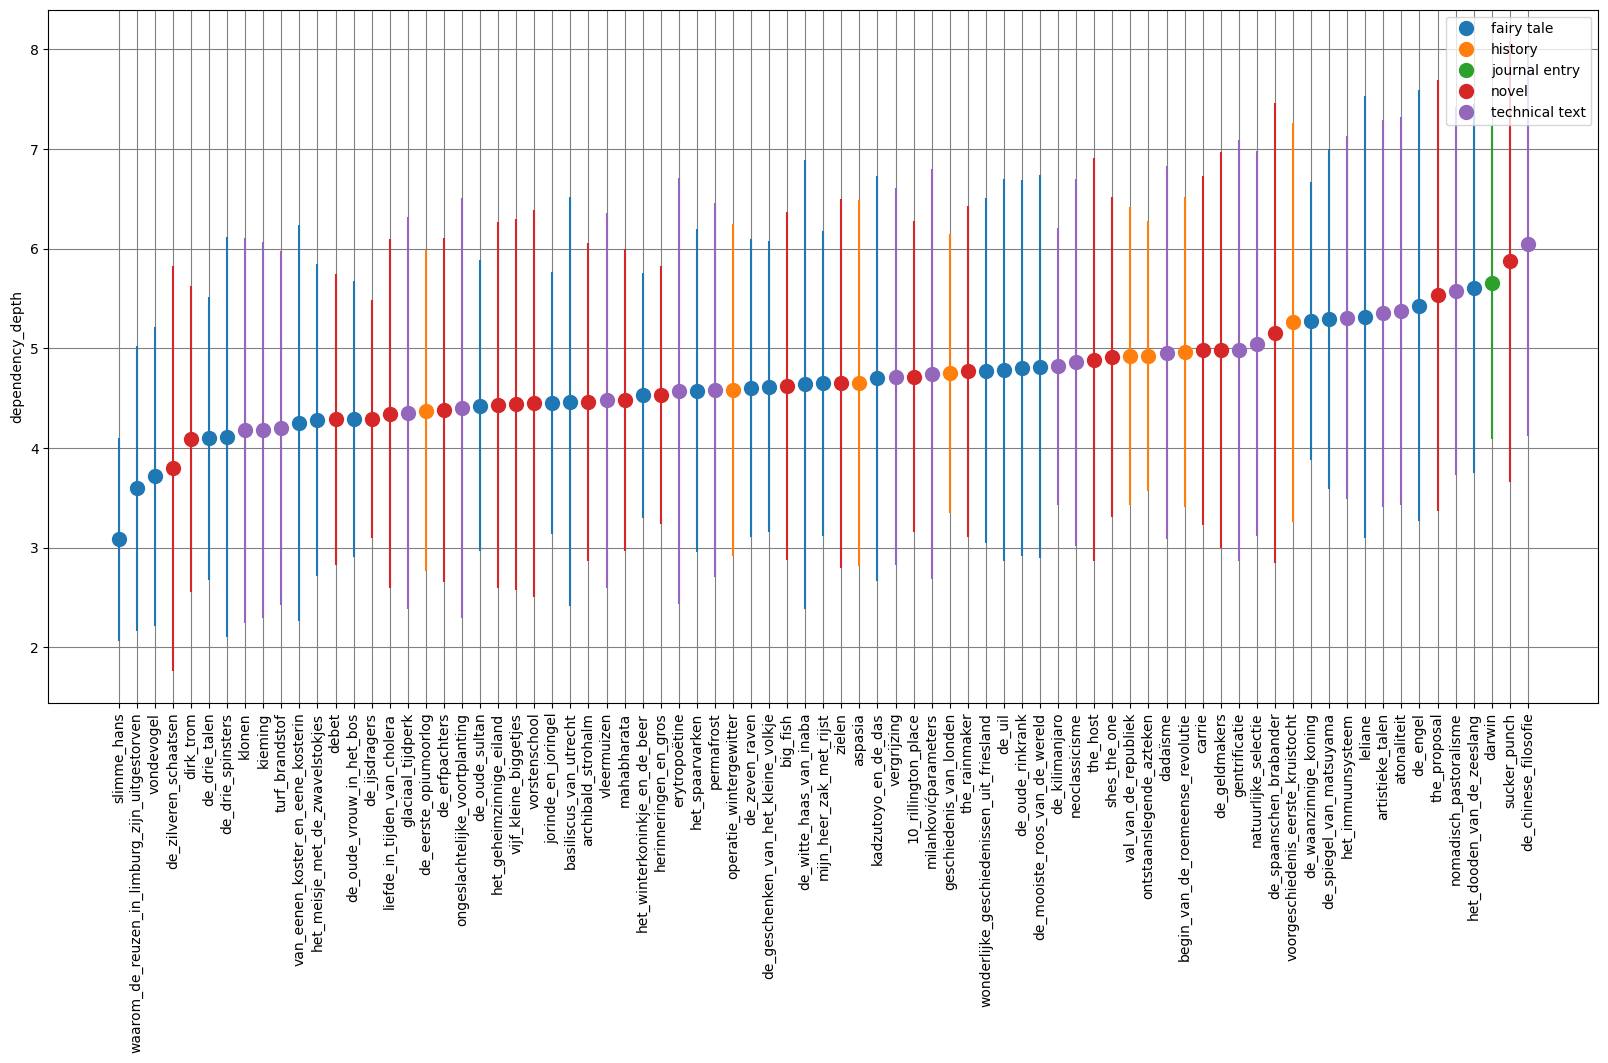

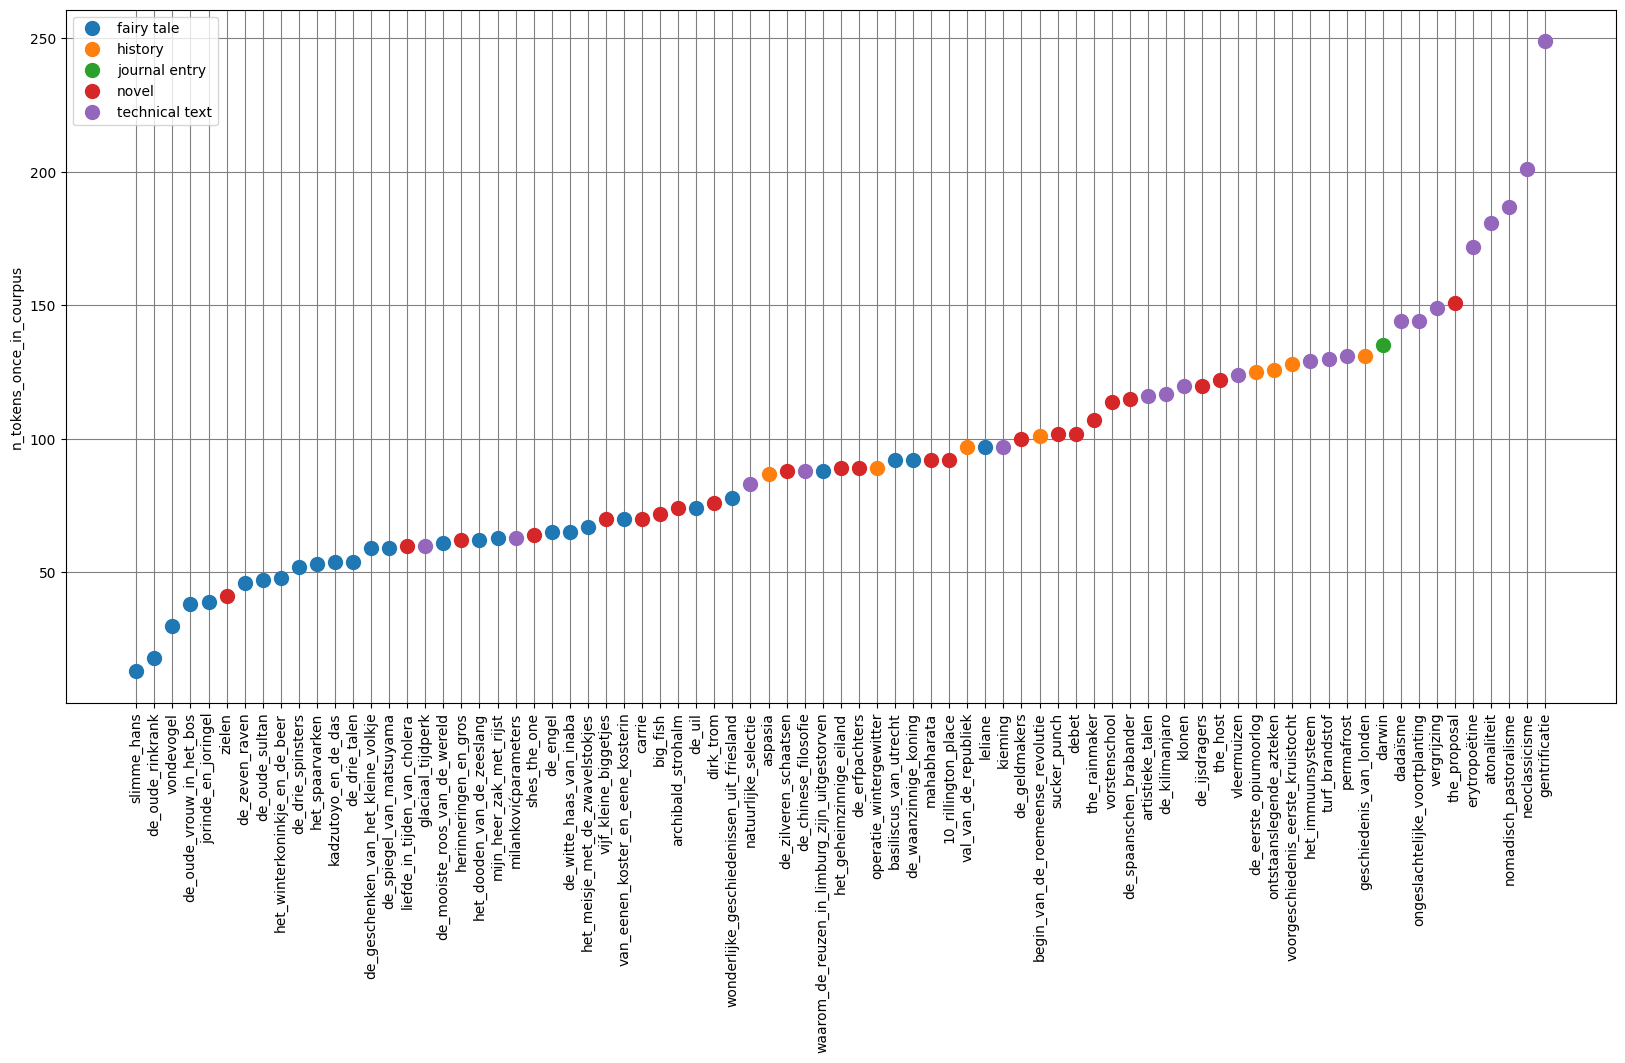

In [132]:
plot_parameters = [
        "token_length",
        "sentence_length",
        "dependency_distance",
        "type_token_ratio",
        "dependency_depth",
        "n_tokens_once_in_courpus",
    ]

for parameter in plot_parameters:
    plot_descriptives(descriptives, parameter, save_fig=False)

**Descriptives summarized for different types of texts**

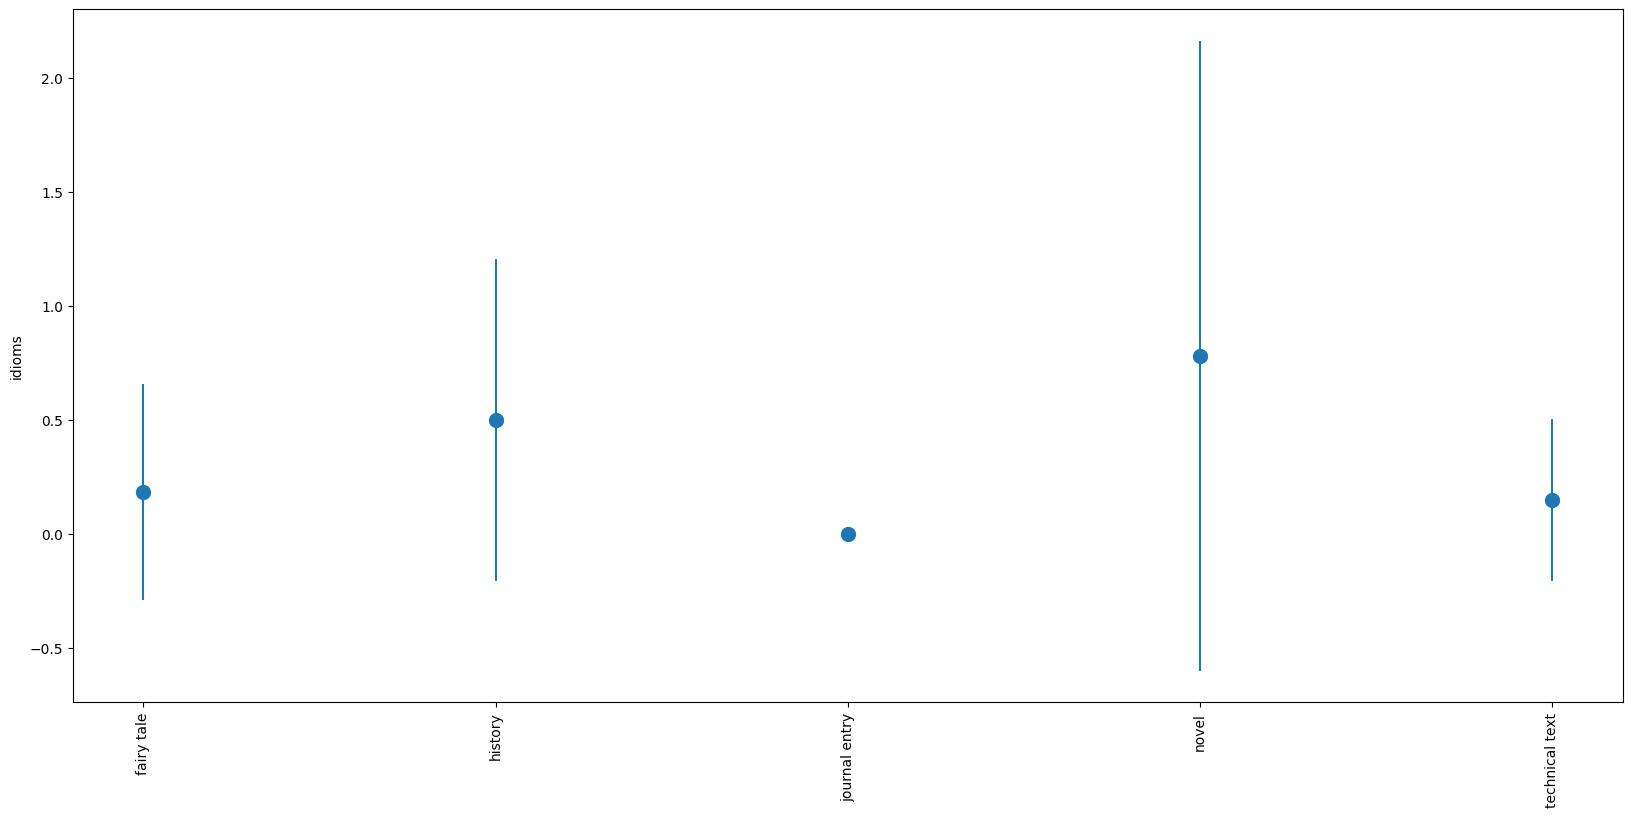

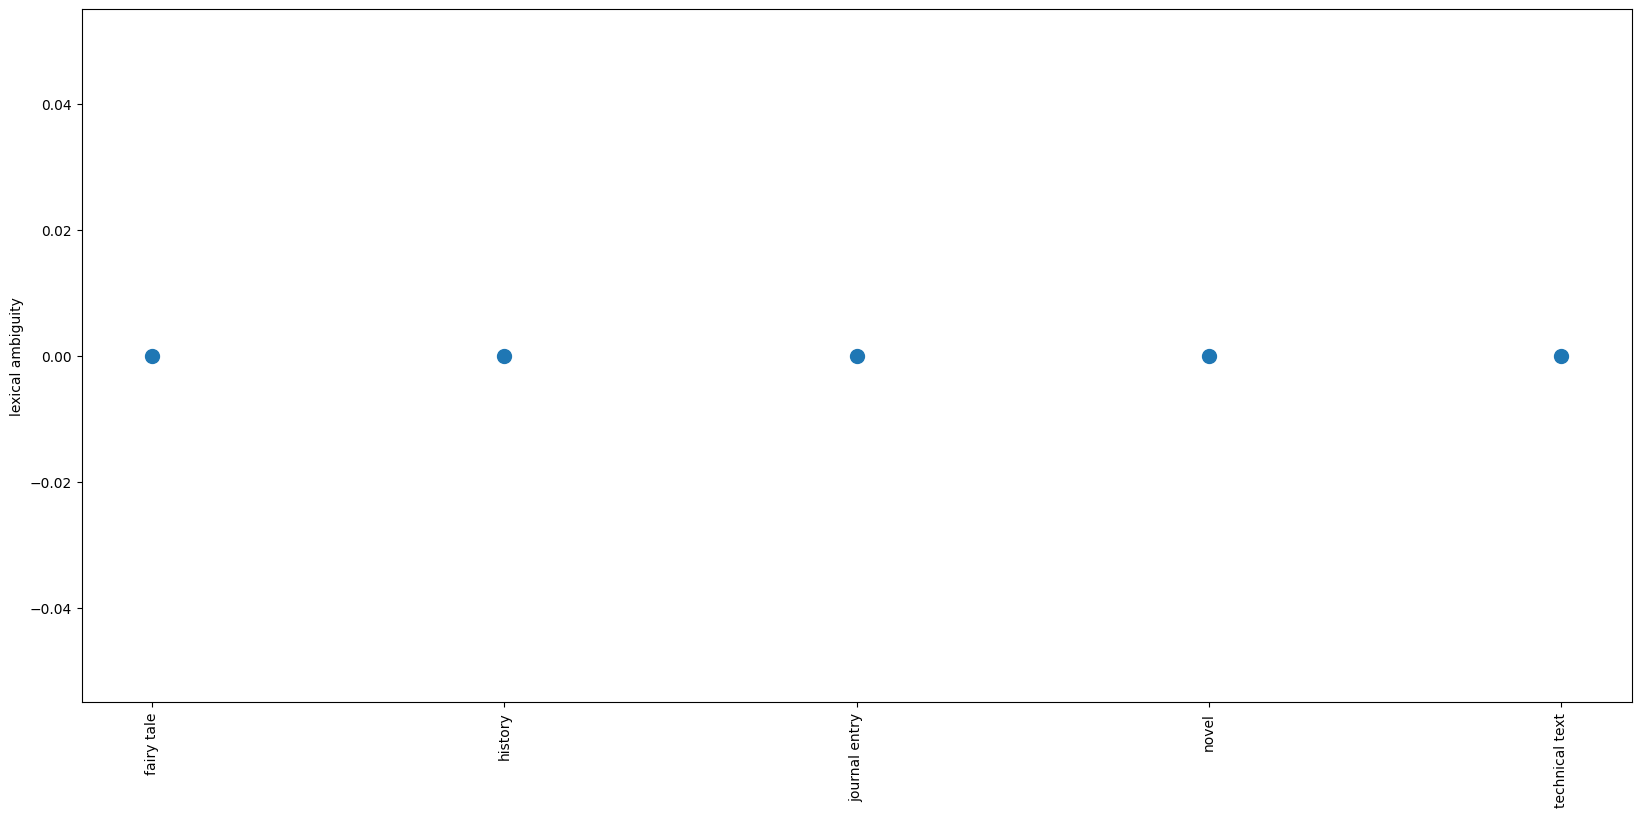

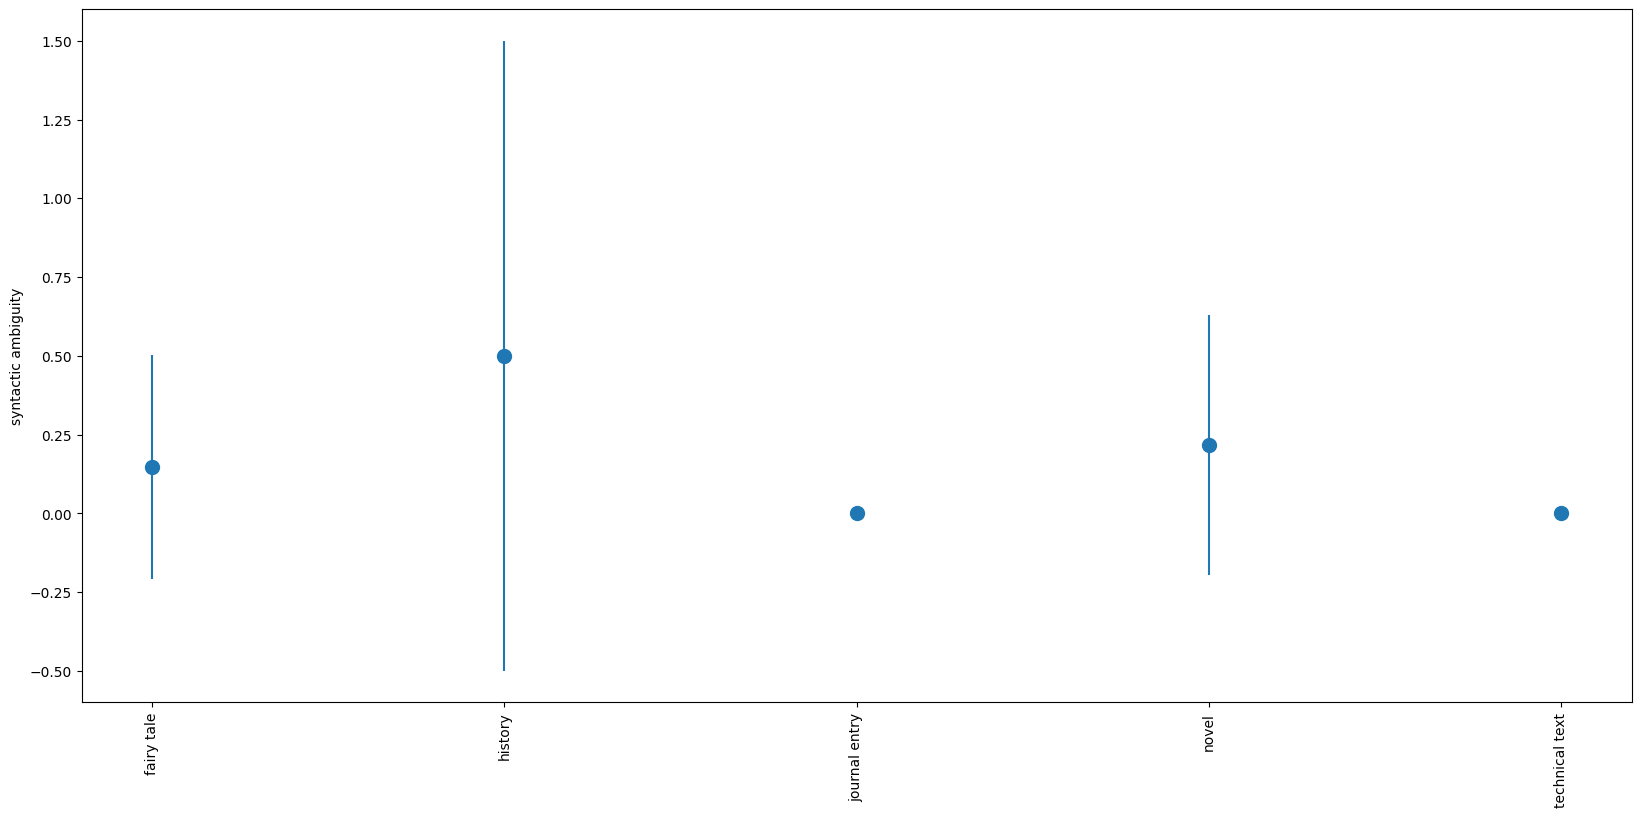

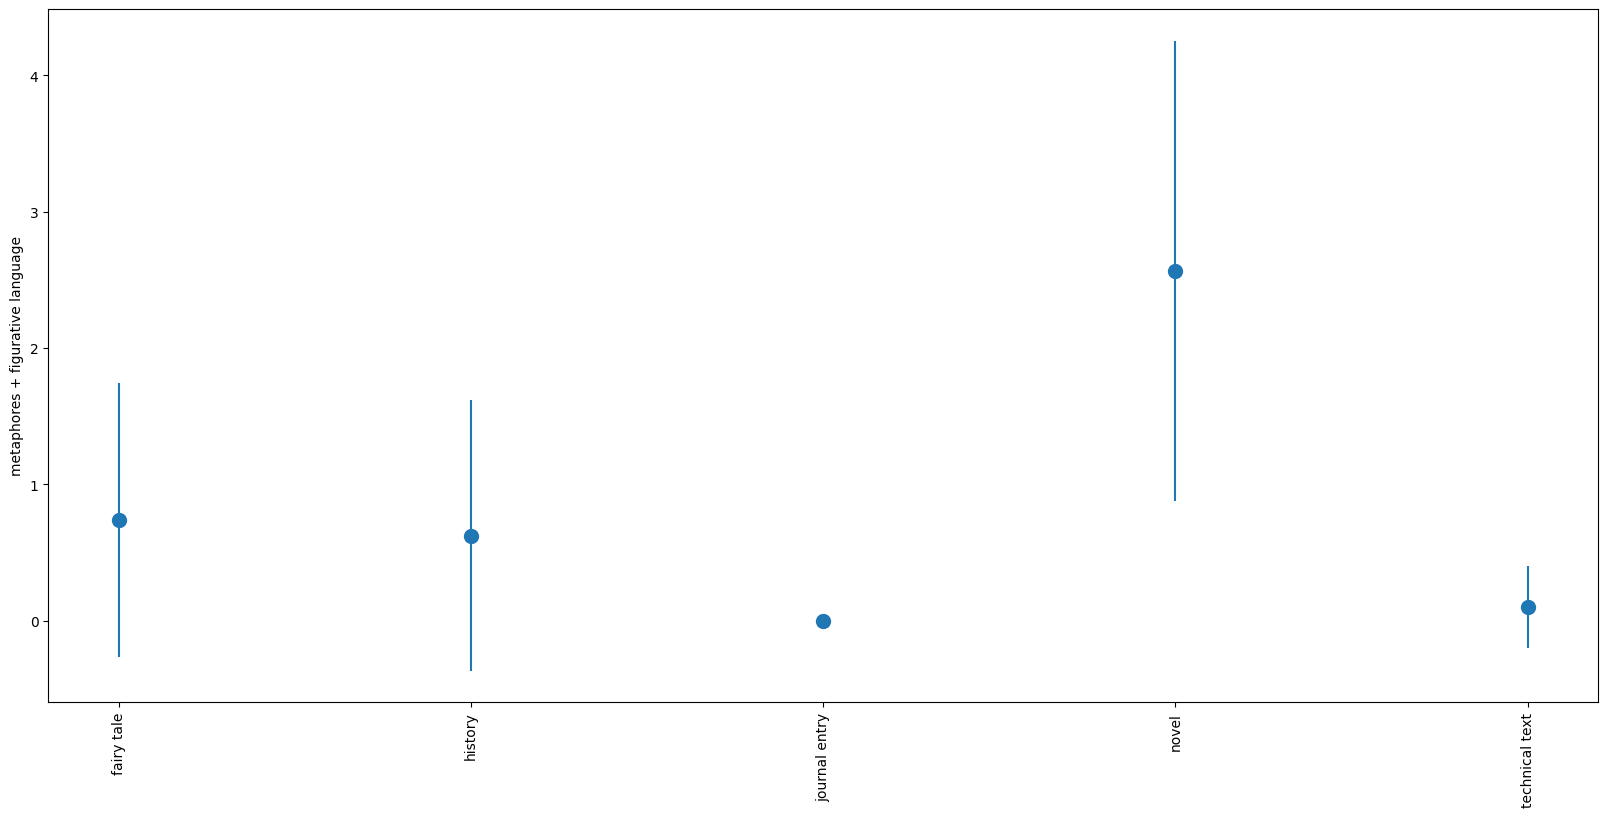

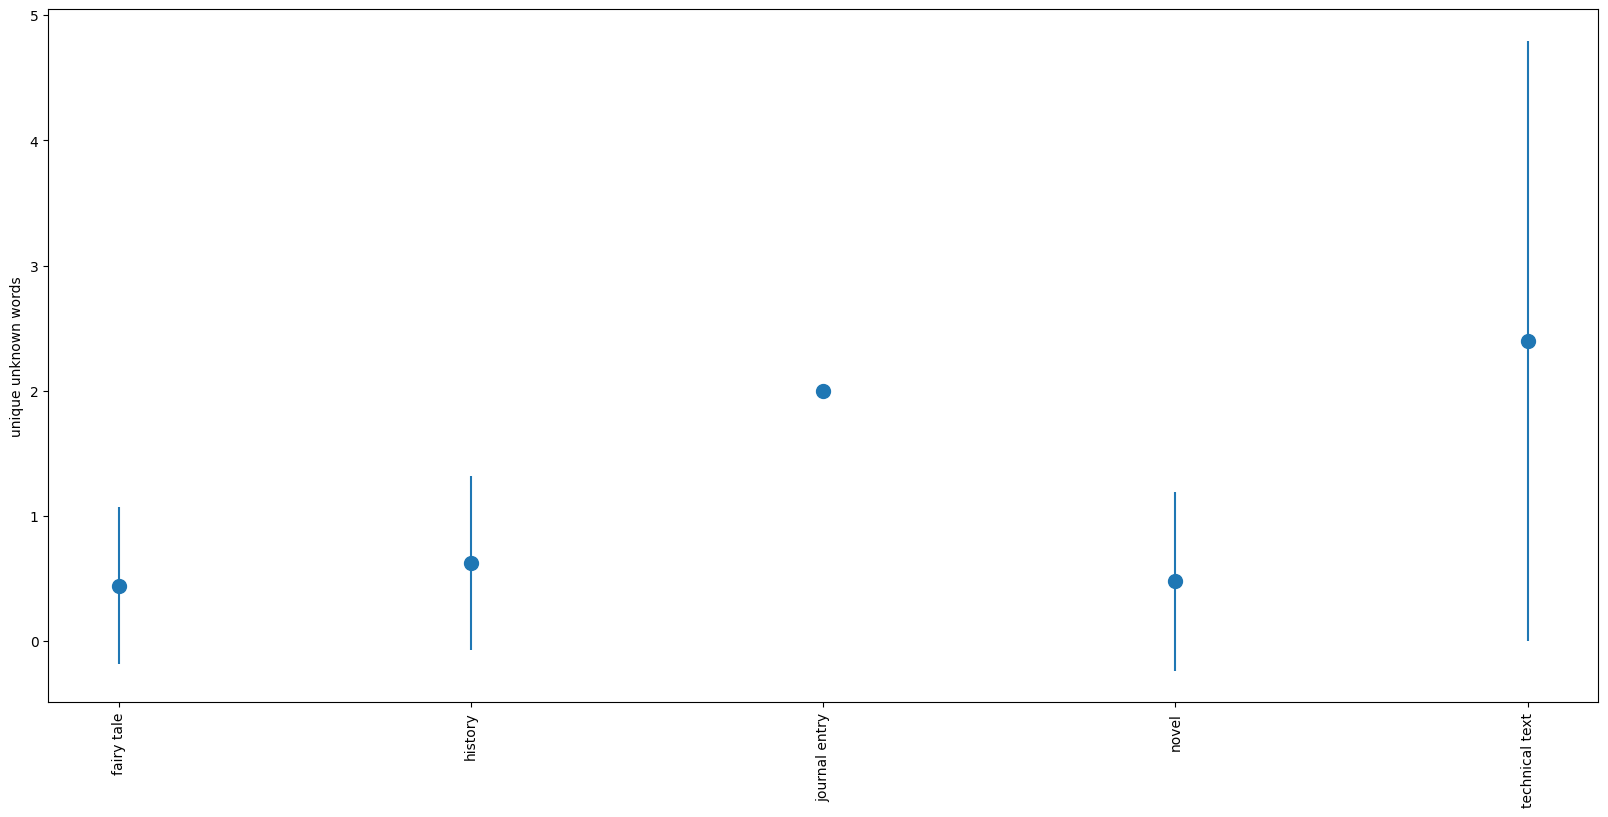

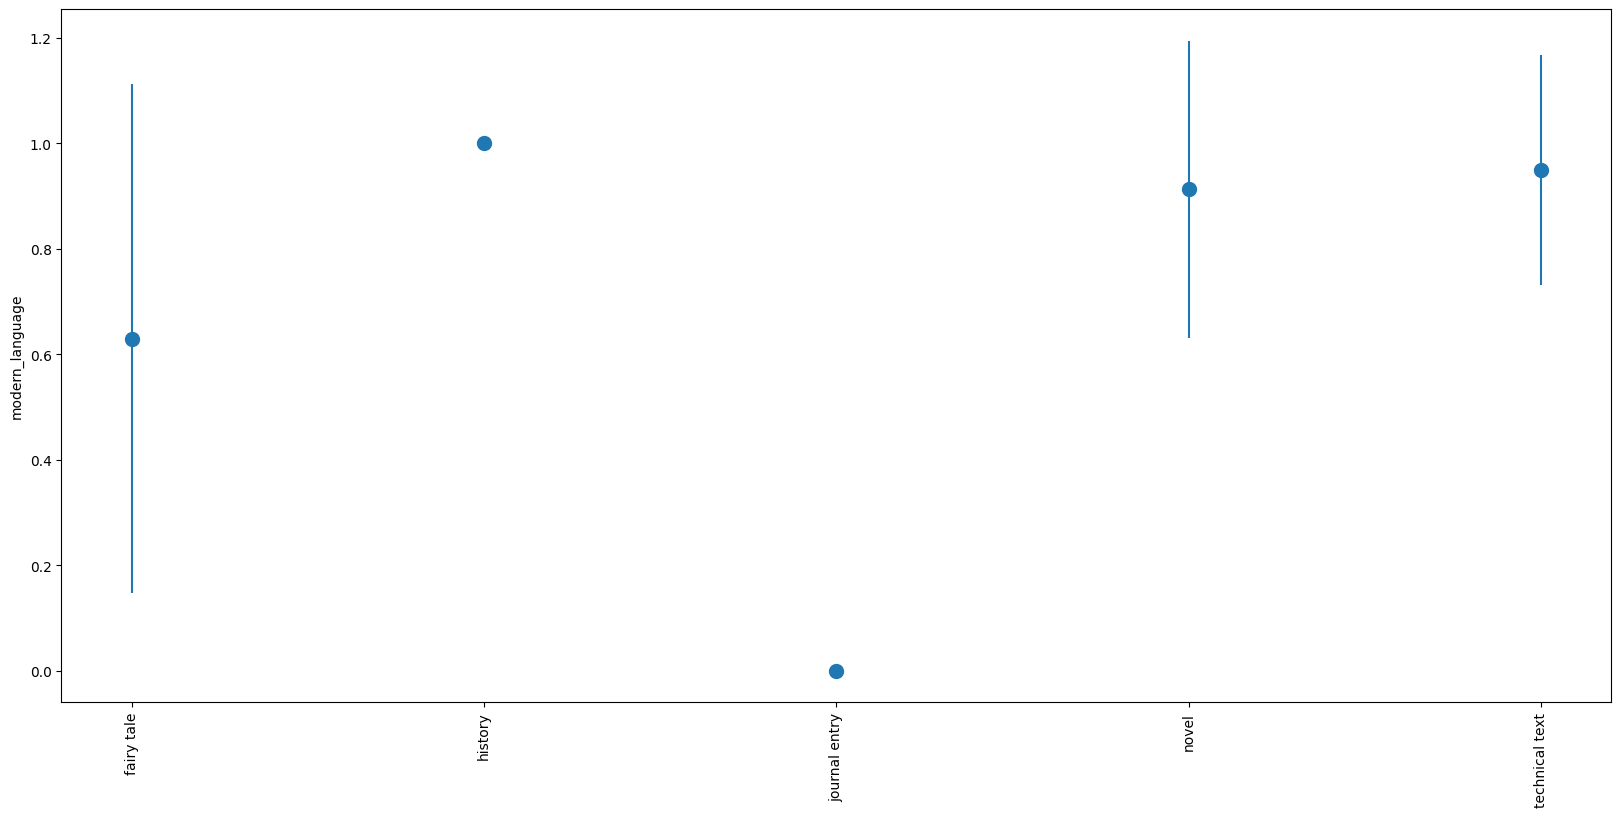

In [133]:
# text parameters contructed by RAs
descriptives["modern_language"] = [
    1 if language=="Modern" or language=="Modern " else 0 for language in descriptives["type of language"]
    ]

plot_parameters = [
        "idioms",
        "lexical ambiguity",
        "syntactic ambiguity",
        "metaphores + figurative language",
        "unique unknown words",
        "modern_language"
    ]

for parameter in plot_parameters:
    plot_descriptives_group_mean(descriptives, parameter, save_fig=True)

**Select texts**

In [141]:
filtered_descriptives = descriptives[descriptives["Lenneke\'s rating (e.g. is the text \"good\" --> interesting/informative and well written). 1 = very bad, 5 = very good"] >= 3]

In [142]:
marked_in_docs = [
    # fairy tale
    1, 22, 48, 50, 51, 11, 15,
    # history
    42, 43, 58,
    # novel/synopsis roman/synopsis scific story
    47, 77, 78, 79
    # technical texts = None
    ]

filtered_descriptives["marked"] = filtered_descriptives["Number"].isin(marked_in_docs)

C:\Users\ostergaa\AppData\Local\Temp\ipykernel_10252\3553246518.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_descriptives["marked"] = filtered_descriptives["Number"].isin(marked_in_docs)


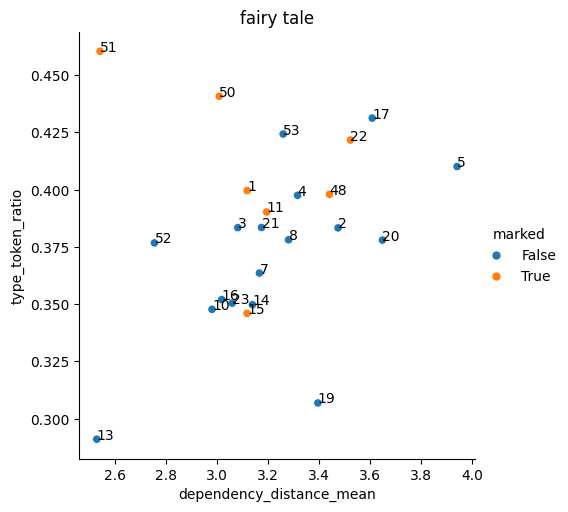

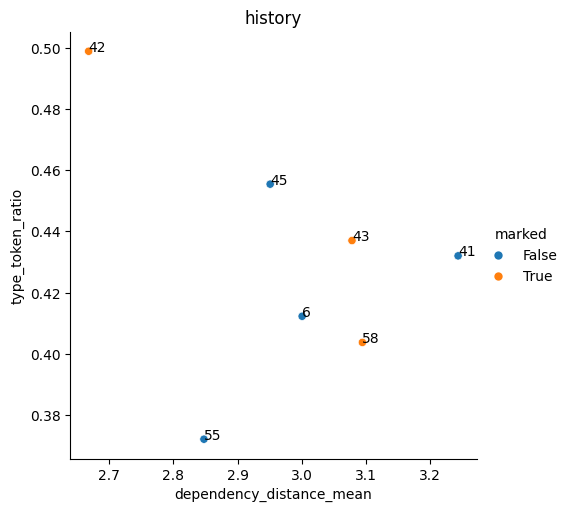

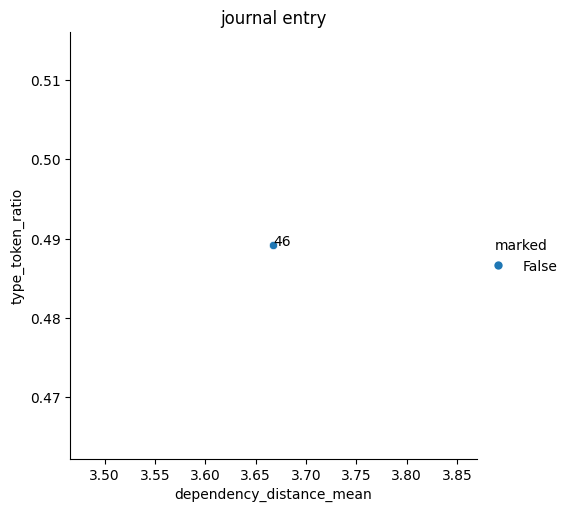

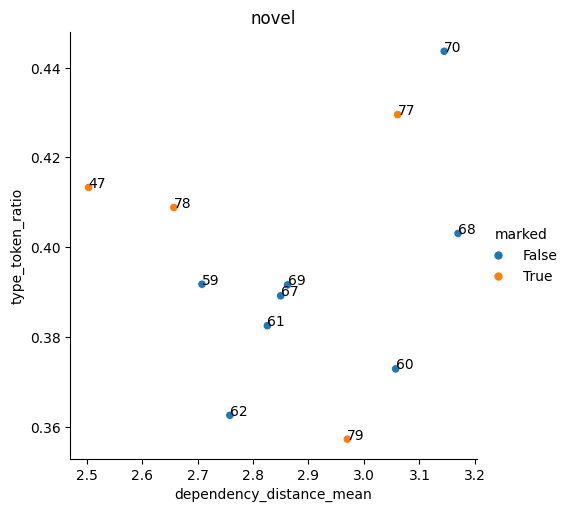

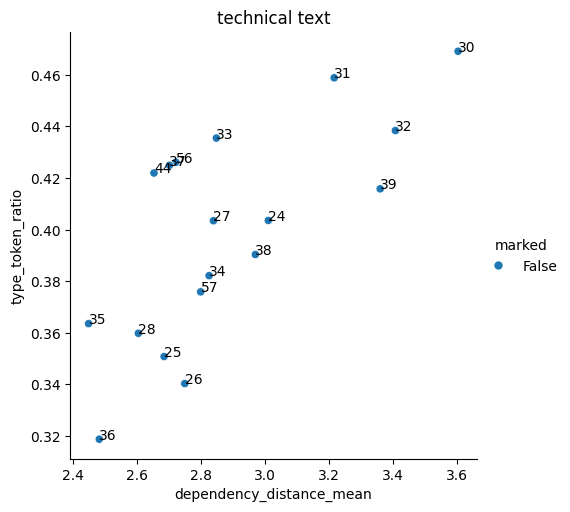

In [143]:
groups = filtered_descriptives.groupby("text_type")

for name, group in groups:
    group = group.reset_index()
    plot_relevant_parameters(
        group, 
        "dependency_distance_mean",
        "type_token_ratio",
        color_parameter="marked",
        title=name)

In [144]:
chosen_fairytales = [1, 51]
chosen_history = [42, 58]
chosen_novel = [47, 77]
chosen_technical = [36, 30, 44, 27]

chosen_texts_number = chosen_fairytales + chosen_history + chosen_novel + chosen_technical

print(f"{len(chosen_texts_number)} texts have been chosen")

10 texts have been chosen


In [145]:
cols_to_check = [
    "Number",
    "text_type",
    "file_name",
    "idioms",
    "syntactic ambiguity",
    "metaphores + figurative language",
    "unique unknown words",
    "type of language"
]

descriptives[descriptives["Number"].isin(chosen_texts_number)][cols_to_check].sort_values(by="text_type")

,Number,text_type,file_name,idioms,syntactic ambiguity,metaphores + figurative language,unique unknown words,type of language
52,1,fairy tale,mijn_heer_zak_met_rijst,0,1,1,2,Old spelling
76,51,fairy tale,waarom_de_reuzen_in_limburg_zijn_uitgestorven,1,0,0,1,Old spelling
3,58,history,aspasia,0,3,0,0,Modern
15,42,history,de_eerste_opiumoorlog,0,0,1,2,Modern
8,77,novel,carrie,3,1,6,1,Modern
32,47,novel,de_zilveren_schaatsen,0,0,0,1,Old spelling
47,36,technical text,kieming,0,0,0,5,Modern
56,30,technical text,nomadisch_pastoralisme,0,0,0,0,Modern
60,27,technical text,permafrost,1,0,0,3,Modern
72,44,technical text,vleermuizen,1,0,0,5,Modern


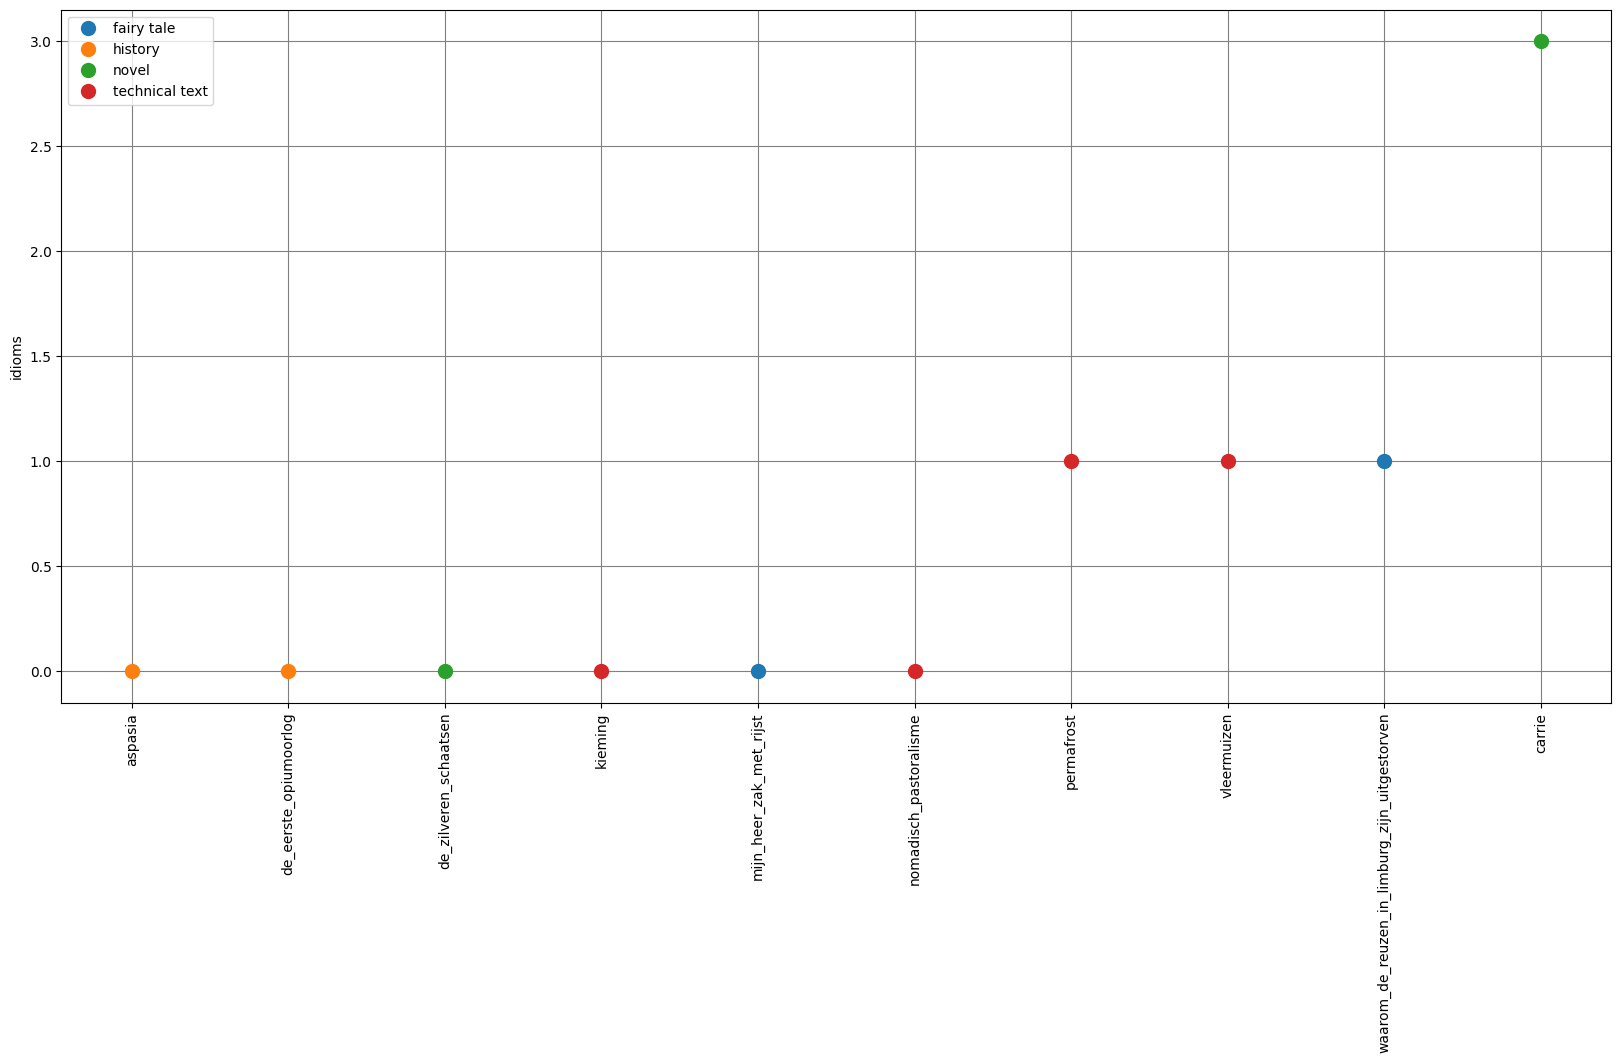

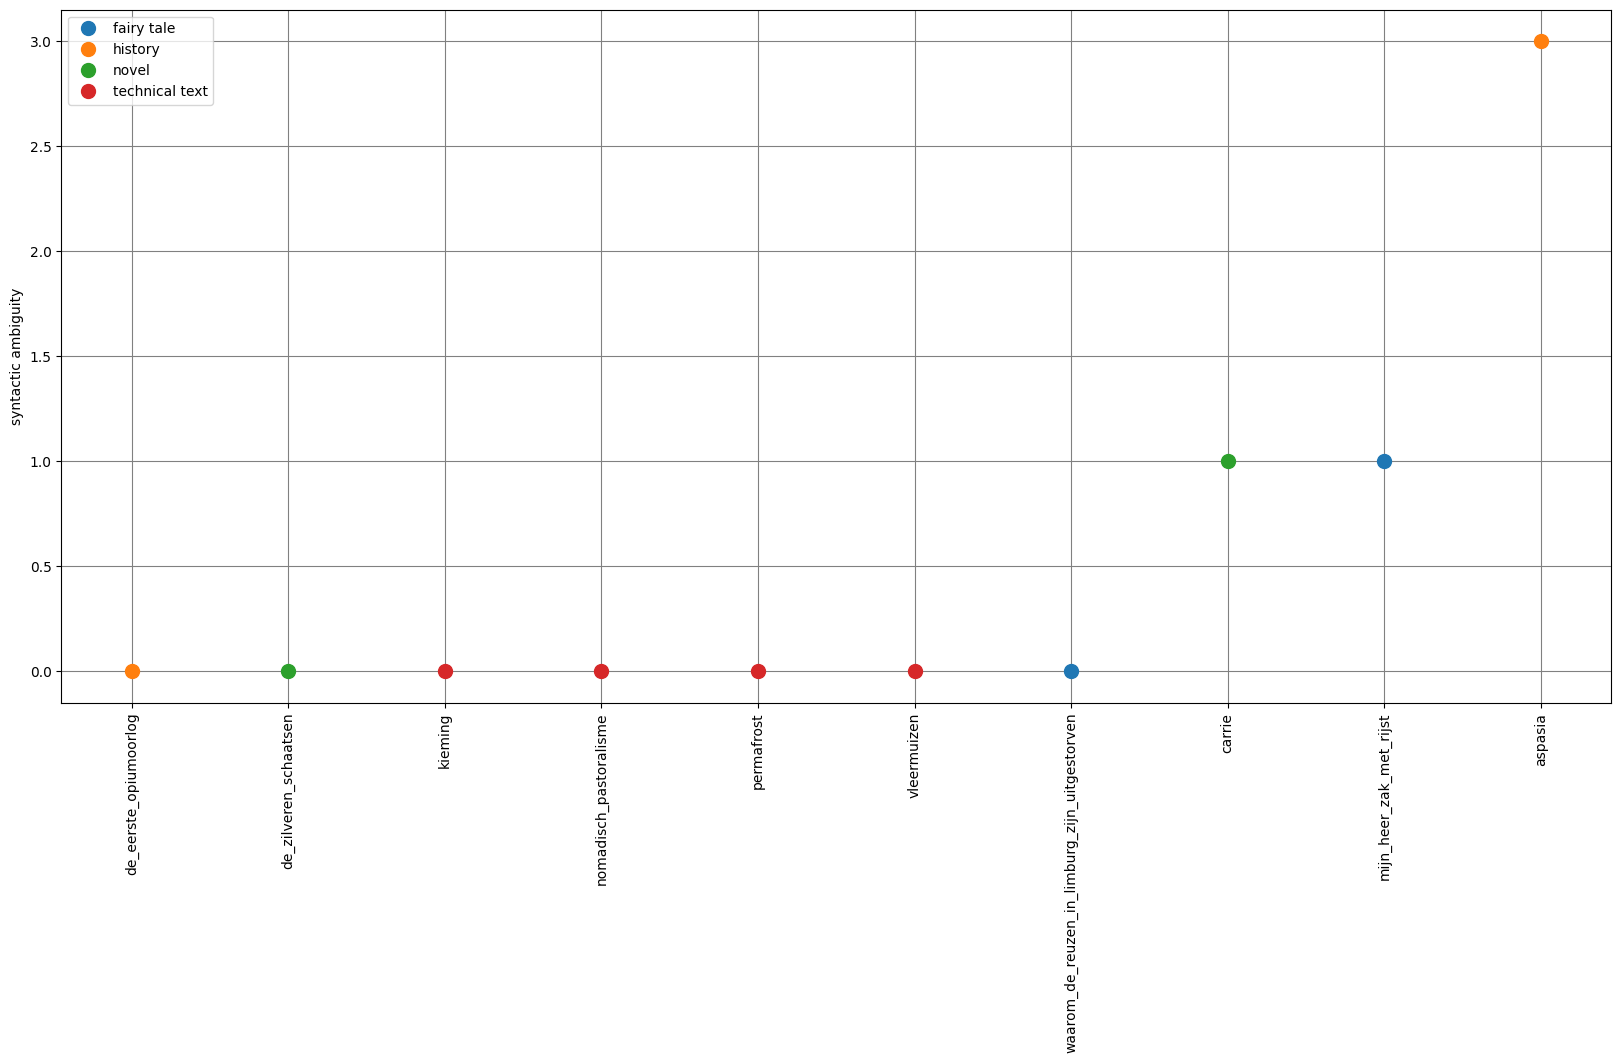

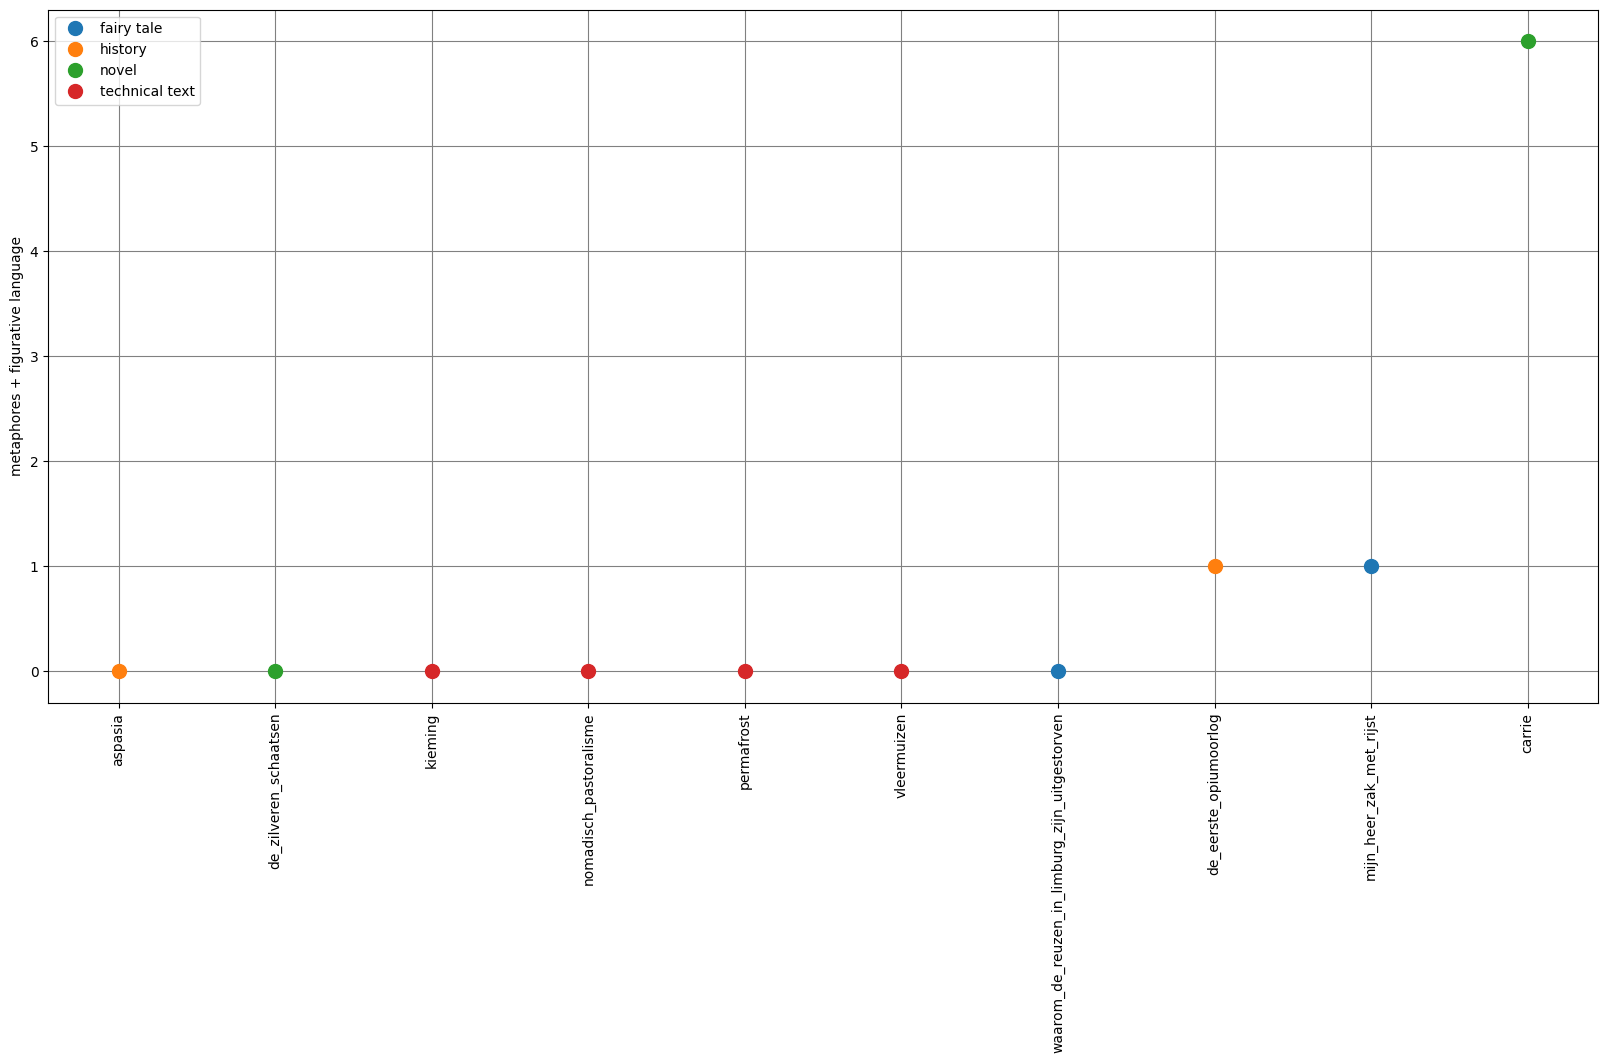

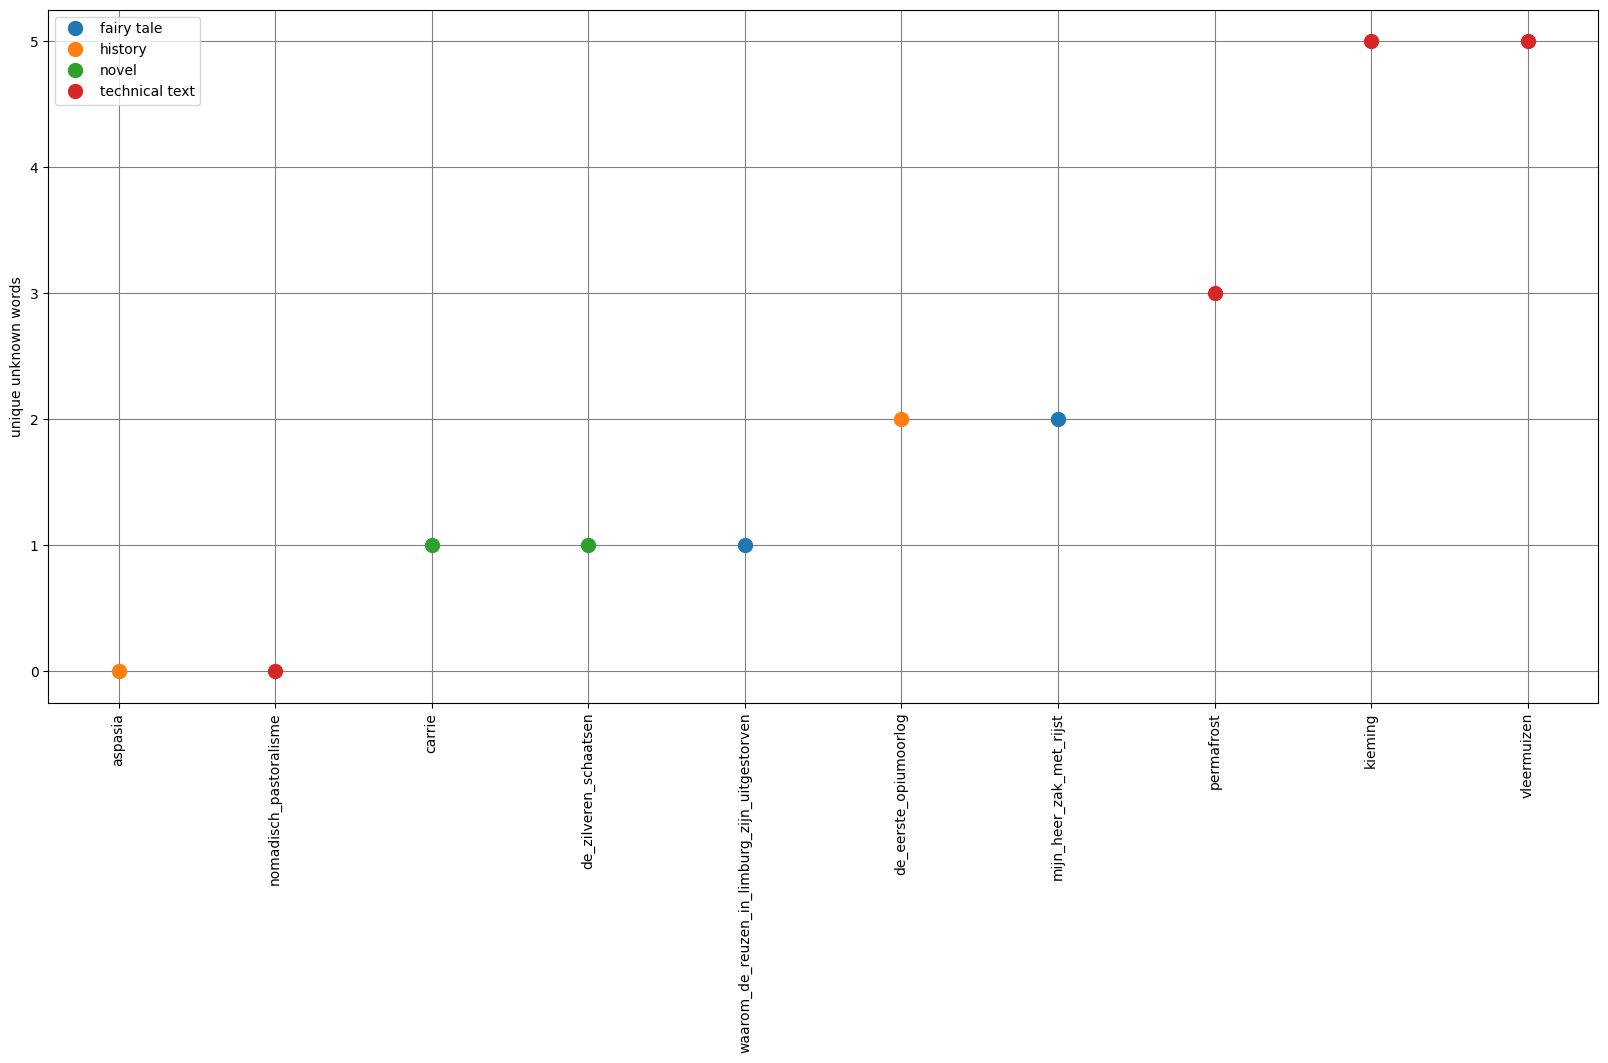

In [146]:
plot_parameters = [
        "idioms",
        "syntactic ambiguity",
        "metaphores + figurative language",
        "unique unknown words"
    ]

for parameter in plot_parameters:
    plot_descriptives(
        descriptives[descriptives["Number"].isin(chosen_texts_number)], 
        parameter, save_fig=False)

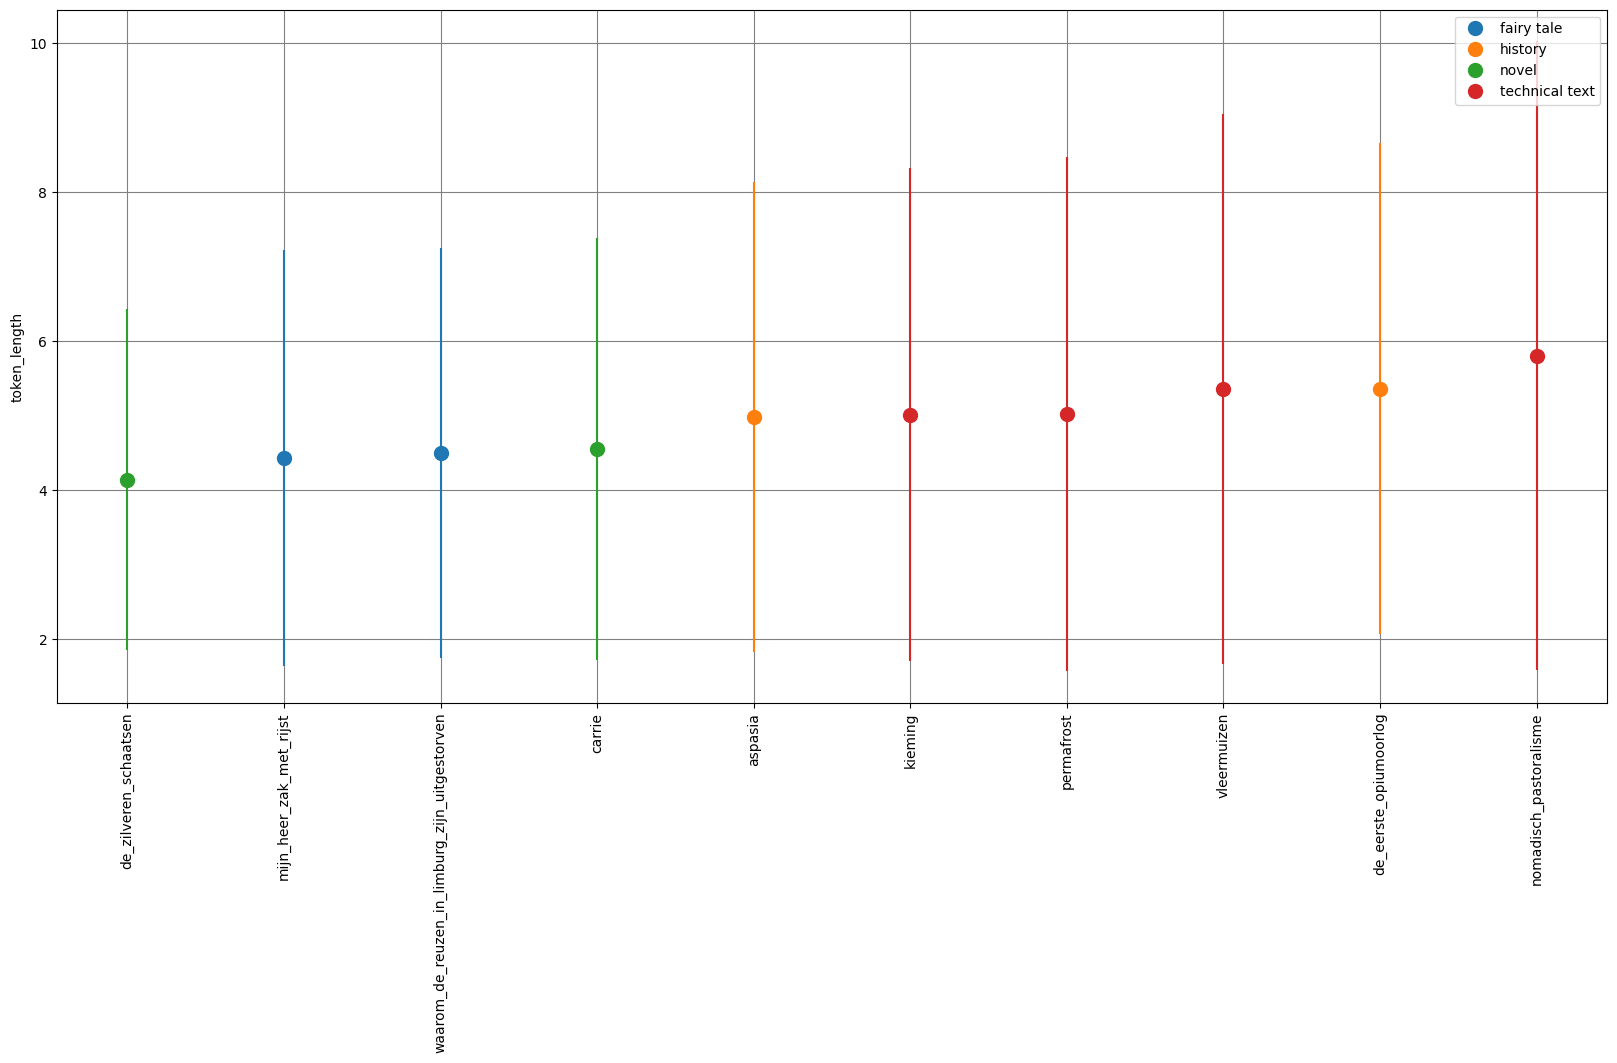

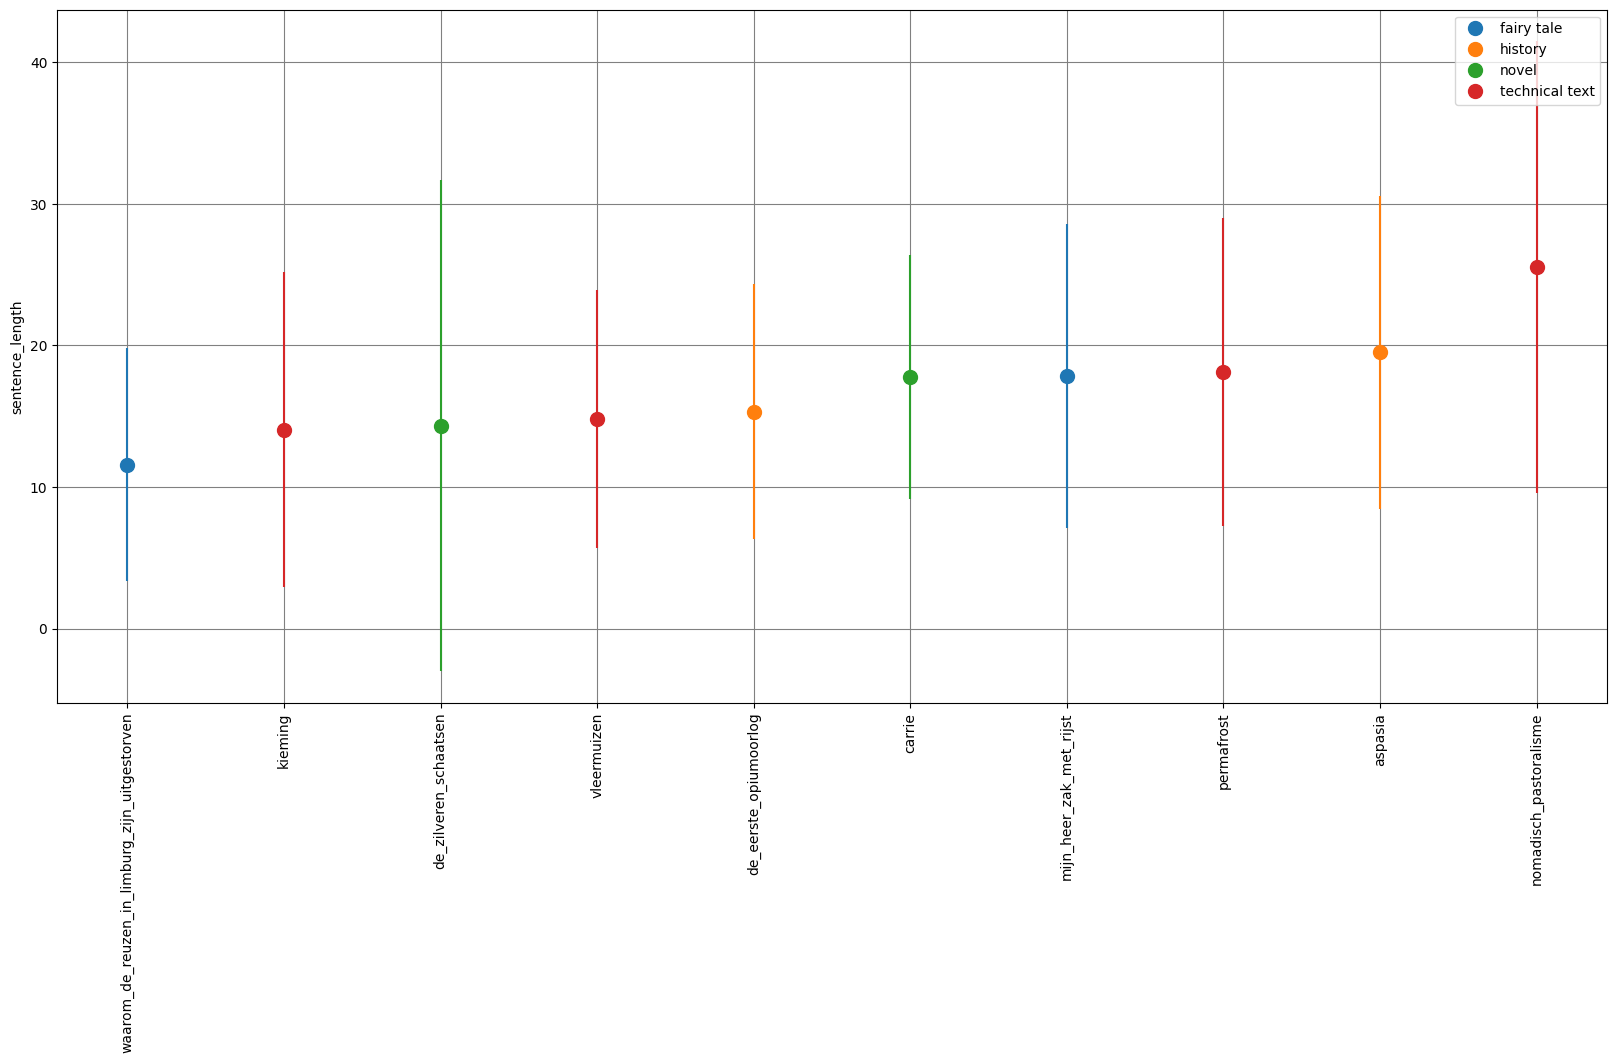

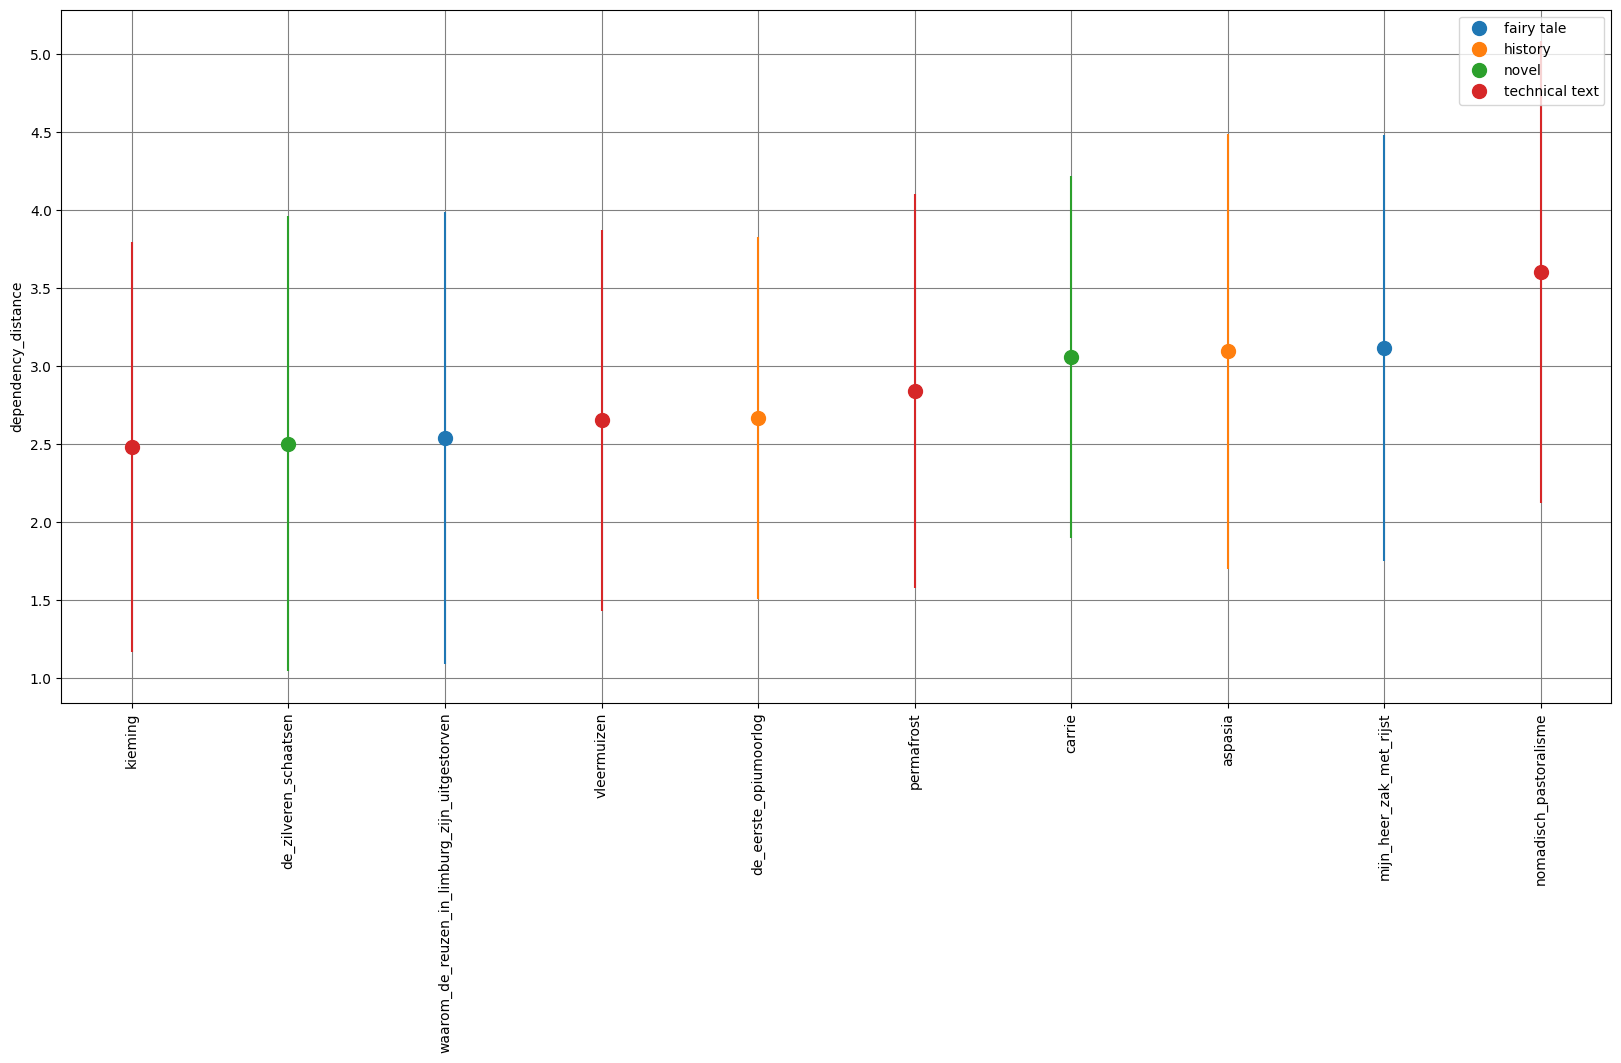

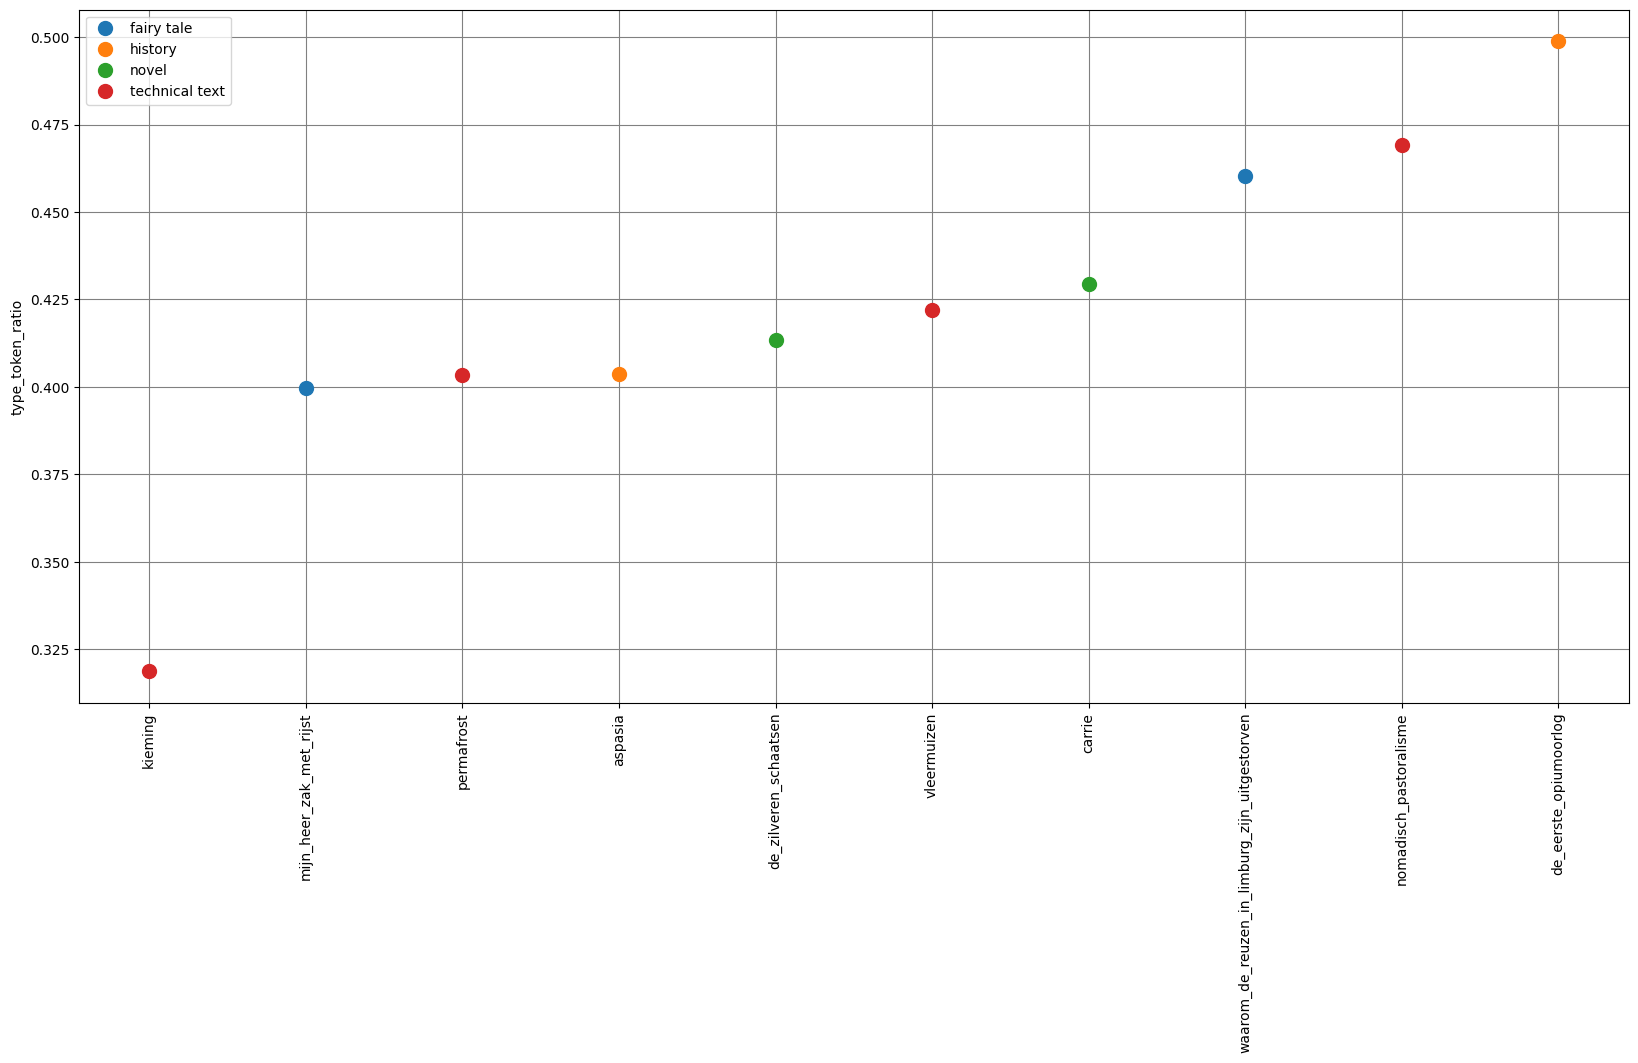

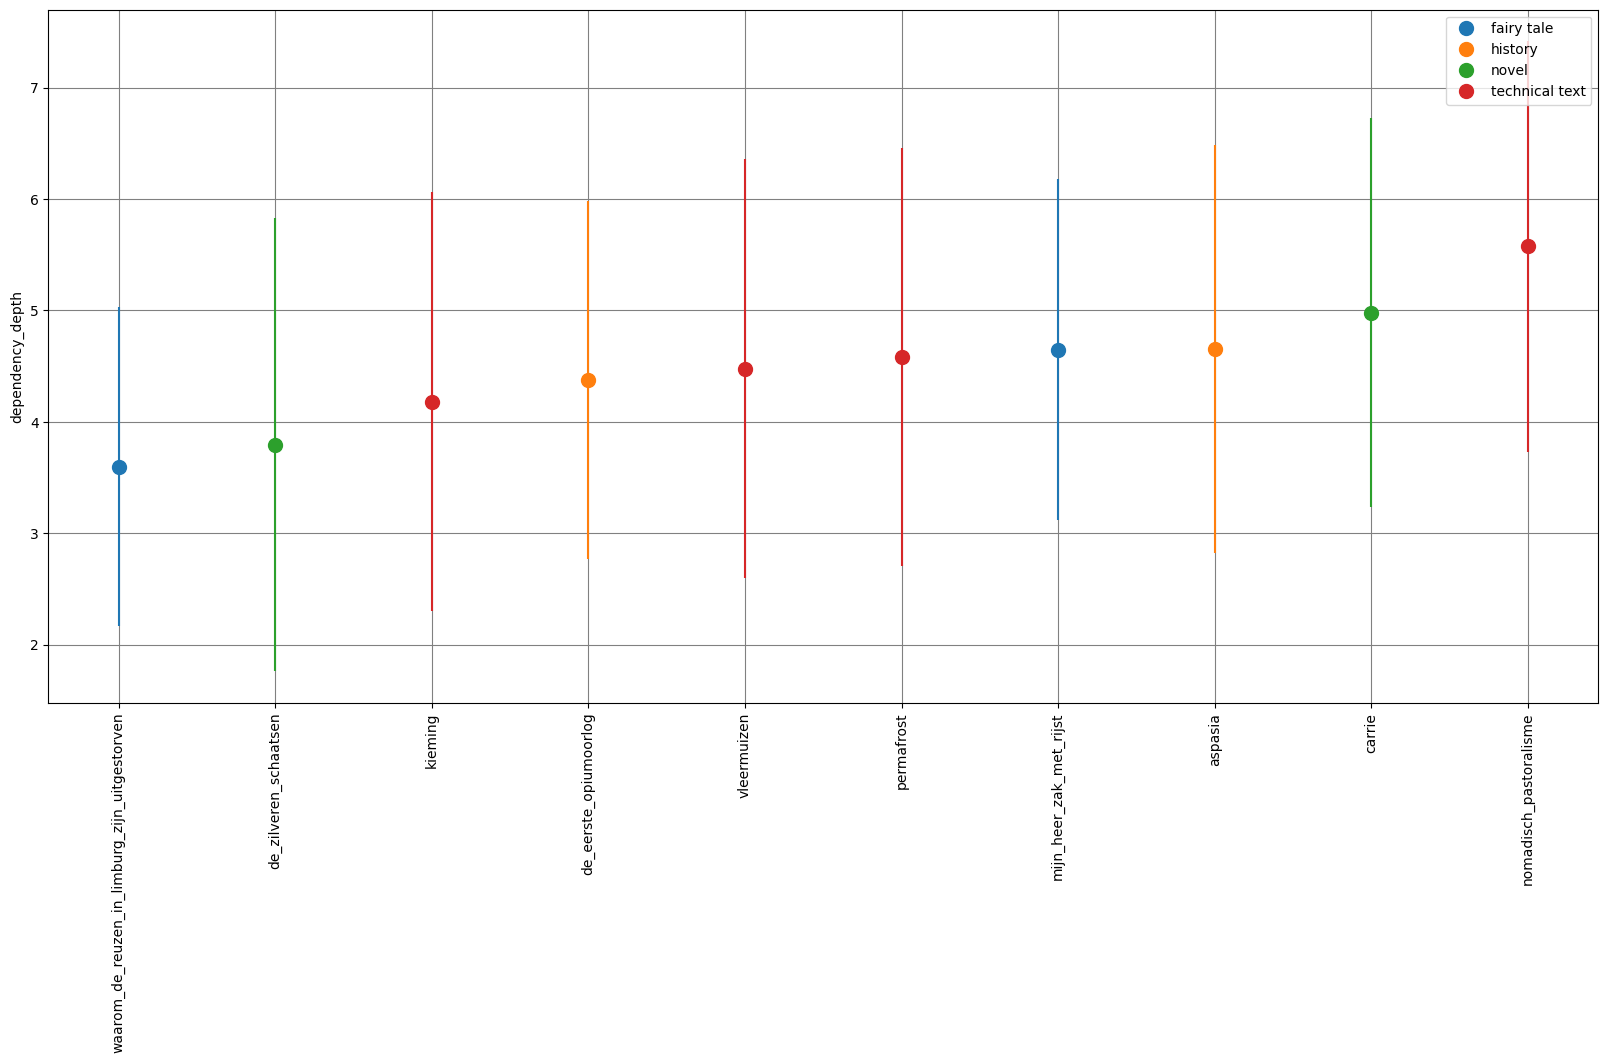

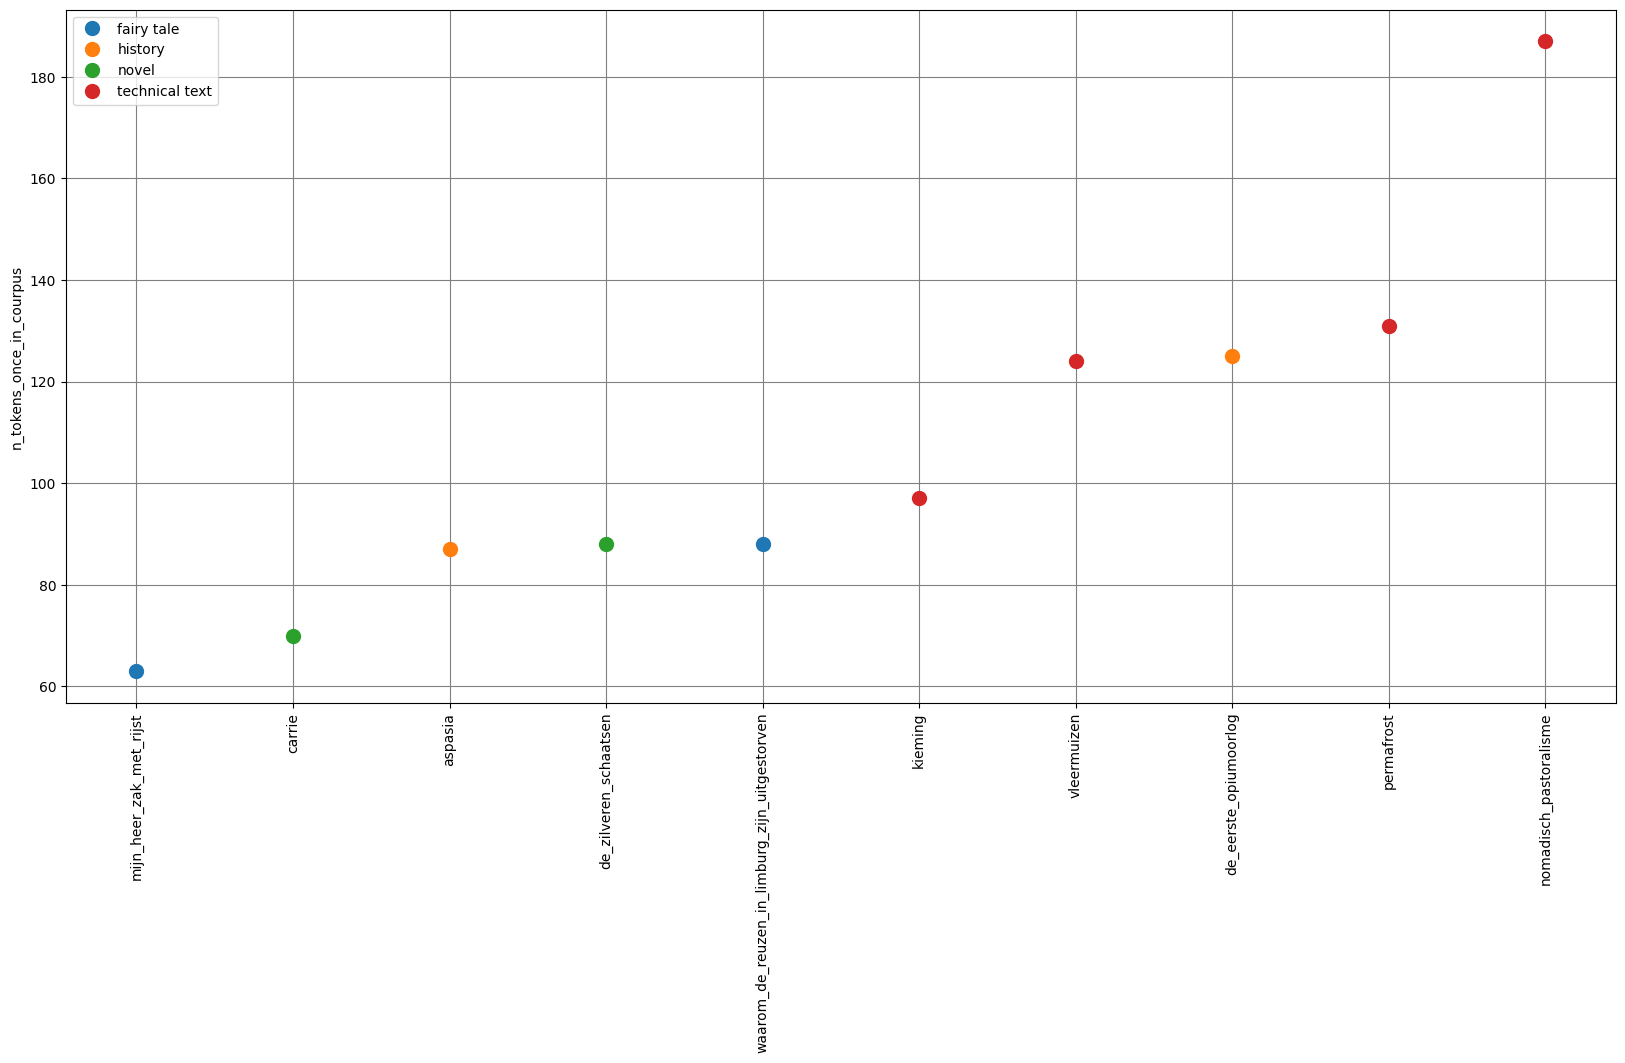

In [147]:
plot_parameters = [
        "token_length",
        "sentence_length",
        "dependency_distance",
        "type_token_ratio",
        "dependency_depth",
        "n_tokens_once_in_courpus",
    ]

for parameter in plot_parameters:
    plot_descriptives(
        descriptives[descriptives["Number"].isin(chosen_texts_number)],
        parameter, save_fig=False)